In [2]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 72.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 103.5 MB/s eta 0:00:0000:0100:01


Train1 - ['sad.jpg', 'saadgirl.jpg', 'happy.jpg', 'data', 'very-happy-people.jpg']
Train2 - ['sad.jpg', 'saadgirl.jpg', 'happy.jpg', 'data', 'very-happy-people.jpg']
['sad.jpg', 'saadgirl.jpg', 'happy.jpg', 'data', 'very-happy-people.jpg']
Train Classes - ['sad', 'happy']
Validation Classes - ['sad', 'happy']


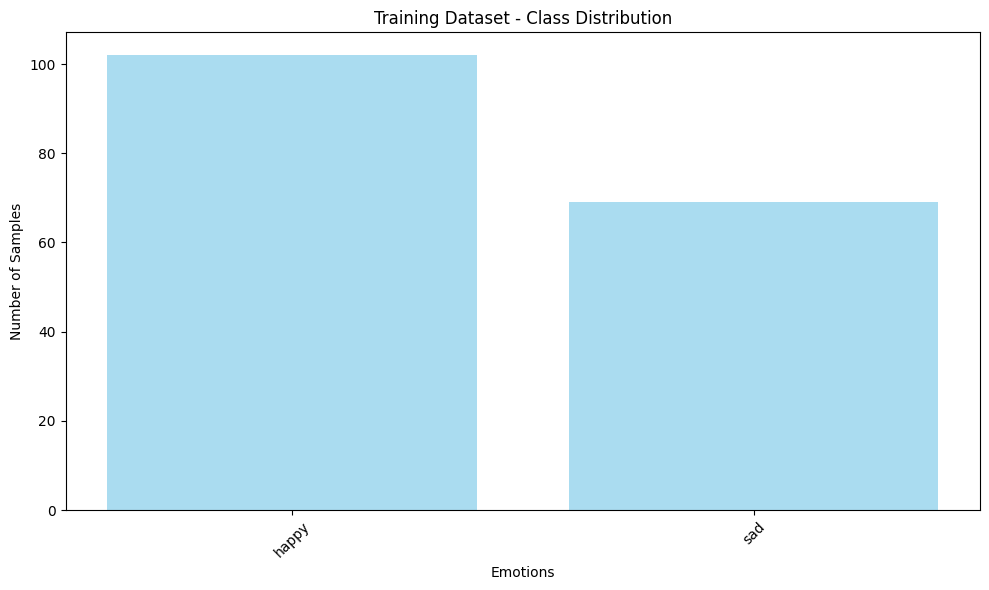

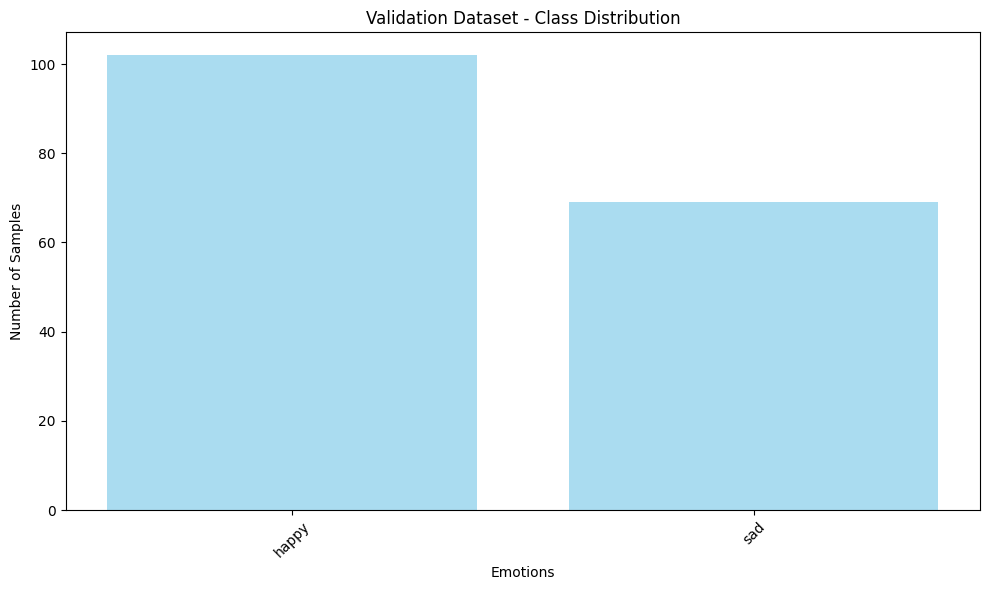

Train images shape: (171, 48, 48, 1)
Test images shape: (171, 48, 48, 1)
Train labels shape: (171, 2)
Test labels shape: (171, 2)


In [3]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report
import itertools
     

# Constants
IMG_SIZE = 48
DATA_DIR = '/kaggle/input/happy-and-sad-image'
     

import os
import torch
import torchvision
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.transforms as tt
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
%matplotlib inline
train1 = os.listdir(DATA_DIR)
train2 = os.listdir(DATA_DIR)
print(f'Train1 - {train1}')
print(f'Train2 - {train2}')
data_dir = DATA_DIR
print(os.listdir(data_dir))
classes_train = os.listdir(data_dir + f"/{train1[3]}")
classes_valid = os.listdir(data_dir + f"/{train2[3]}")
print(f'Train Classes - {classes_train}')
print(f'Validation Classes - {classes_valid}')
     
import torchvision.transforms as transforms

# Define transforms
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])
     

import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

# Load the datasets
train_dataset = ImageFolder(root=os.path.join(DATA_DIR, train1[3]), transform=transform)
val_dataset = ImageFolder(root=os.path.join(DATA_DIR, train2[3]), transform=transform)
     
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

# Load the datasets
train_dataset = ImageFolder(root=os.path.join(DATA_DIR, train1[3]), transform=transform)
val_dataset = ImageFolder(root=os.path.join(DATA_DIR, train2[3]), transform=transform)
     

def plot_class_distribution(dataset, title):
    class_counts = {}
    for _, label in dataset:
        class_name = emotion_labels[label]
        class_counts[class_name] = class_counts.get(class_name, 0) + 1

    plt.figure(figsize=(10, 6))
    plt.bar(class_counts.keys(), class_counts.values(), color='skyblue', alpha=0.7)
    plt.title(f'{title} - Class Distribution')
    plt.xlabel('Emotions')
    plt.ylabel('Number of Samples')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return class_counts

# Define emotion_labels based on the dataset classes
emotion_labels = {i: class_name for i, class_name in enumerate(train_dataset.classes)}

train_counts = plot_class_distribution(train_dataset, 'Training Dataset')
val_counts = plot_class_distribution(val_dataset, 'Validation Dataset')


def dataset_to_numpy(dataset, n_samples):
    images = []
    labels = []
    # Use the actual number of samples available in the dataset
    num_samples_to_extract = min(n_samples, len(dataset))
    for i in range(num_samples_to_extract):
        img_tensor, label = dataset[i]
        img_array = img_tensor.numpy().transpose(1, 2, 0)  # (1, 48, 48) → (48, 48, 1)
        images.append(img_array)
        labels.append(label)
    return np.array(images), np.array(labels)

# Define number of samples to extract (these values will be capped by the actual dataset size)
n_train = 5000
n_test = 3000

train_images, train_labels = dataset_to_numpy(train_dataset, n_train)
test_images, test_labels = dataset_to_numpy(val_dataset, n_test)

# Clip values (just in case)
train_images = np.clip(train_images, 0.0, 1.0)
test_images = np.clip(test_images, 0.0, 1.0)

# One-hot encode labels
train_labels_categorical = to_categorical(train_labels, num_classes=len(emotion_labels))
test_labels_categorical = to_categorical(test_labels, num_classes=len(emotion_labels))


print(f"Train images shape: {train_images.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Train labels shape: {train_labels_categorical.shape}")
print(f"Test labels shape: {test_labels_categorical.shape}")

Train set class counts:
  Sad       : 102 samples
  Happy     : 69 samples

Test set class counts:
  Sad       : 102 samples
  Happy     : 69 samples
Running experiments for 4 Qubits

Running seed 0 for 4 qubits 


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1762835829.961247     547 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1762835829.961954     547 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/9


I0000 00:00:1762835831.523567     608 service.cc:148] XLA service 0x79f95c0073c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762835831.523600     608 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1762835831.523604     608 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1762835831.660502     608 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1762835832.409227     608 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6/6 - 3s - 507ms/step - accuracy: 0.6316 - loss: 0.6723 - val_accuracy: 0.7778 - val_loss: 0.4741
Epoch 2/9
6/6 - 0s - 16ms/step - accuracy: 0.7544 - loss: 0.4855 - val_accuracy: 0.8480 - val_loss: 0.3871
Epoch 3/9
6/6 - 0s - 15ms/step - accuracy: 0.8246 - loss: 0.3898 - val_accuracy: 0.8889 - val_loss: 0.3286
Epoch 4/9
6/6 - 0s - 15ms/step - accuracy: 0.8947 - loss: 0.3275 - val_accuracy: 0.9064 - val_loss: 0.2719
Epoch 5/9
6/6 - 0s - 14ms/step - accuracy: 0.9006 - loss: 0.3015 - val_accuracy: 0.9240 - val_loss: 0.2285
Epoch 6/9
6/6 - 0s - 15ms/step - accuracy: 0.9298 - loss: 0.2169 - val_accuracy: 0.9123 - val_loss: 0.2001
Epoch 7/9
6/6 - 0s - 14ms/step - accuracy: 0.9357 - loss: 0.1891 - val_accuracy: 0.9532 - val_loss: 0.1624
Epoch 8/9
6/6 - 0s - 14ms/step - accuracy: 0.9591 - loss: 0.1758 - val_accuracy: 0.9591 - val_loss: 0.1377
Epoch 9/9
6/6 - 0s - 14ms/step - accuracy: 0.9591 - loss: 0.1512 - val_accuracy: 0.9825 - val_loss: 0.1188
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

Classif

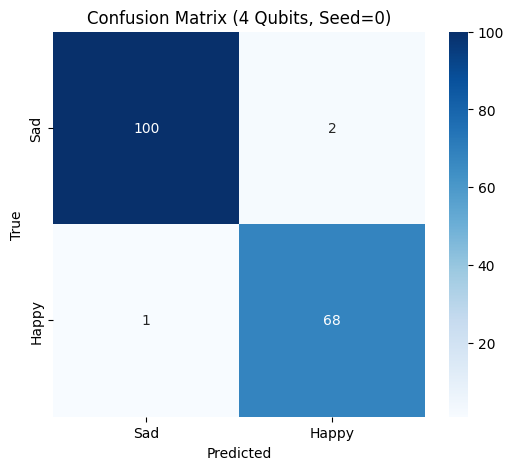

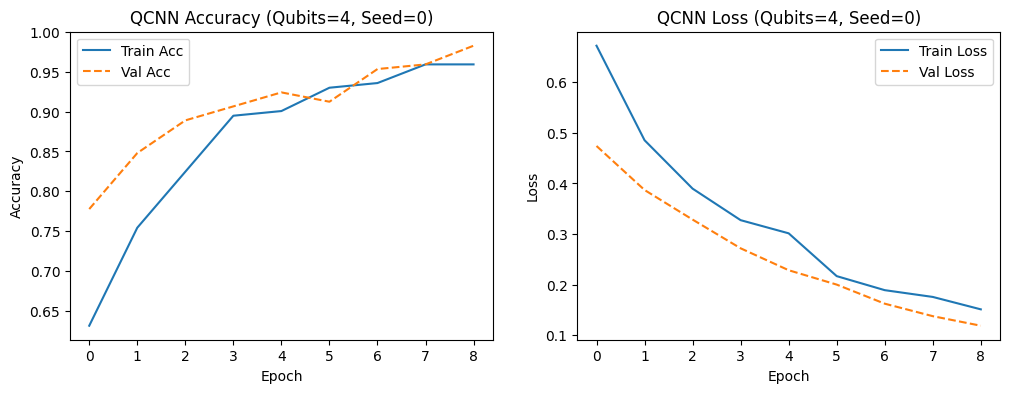


Running seed 1 for 4 qubits 
Epoch 1/9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 2s - 409ms/step - accuracy: 0.6491 - loss: 0.6079 - val_accuracy: 0.7836 - val_loss: 0.4630
Epoch 2/9
6/6 - 0s - 15ms/step - accuracy: 0.7368 - loss: 0.4771 - val_accuracy: 0.8304 - val_loss: 0.3949
Epoch 3/9
6/6 - 0s - 15ms/step - accuracy: 0.8012 - loss: 0.4234 - val_accuracy: 0.8772 - val_loss: 0.3256
Epoch 4/9
6/6 - 0s - 15ms/step - accuracy: 0.8713 - loss: 0.3432 - val_accuracy: 0.8947 - val_loss: 0.2757
Epoch 5/9
6/6 - 0s - 15ms/step - accuracy: 0.9006 - loss: 0.2949 - val_accuracy: 0.9181 - val_loss: 0.2291
Epoch 6/9
6/6 - 0s - 15ms/step - accuracy: 0.9357 - loss: 0.2238 - val_accuracy: 0.9415 - val_loss: 0.1937
Epoch 7/9
6/6 - 0s - 15ms/step - accuracy: 0.9240 - loss: 0.2201 - val_accuracy: 0.9649 - val_loss: 0.1640
Epoch 8/9
6/6 - 0s - 15ms/step - accuracy: 0.9474 - loss: 0.1859 - val_accuracy: 0.9766 - val_loss: 0.1390
Epoch 9/9
6/6 - 0s - 15ms/step - accuracy: 0.9708 - loss: 0.1416 - val_accuracy: 0.9766 - val_loss: 0.1168
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

Classif

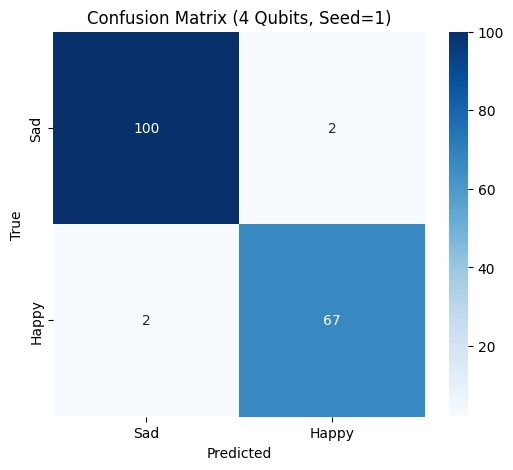

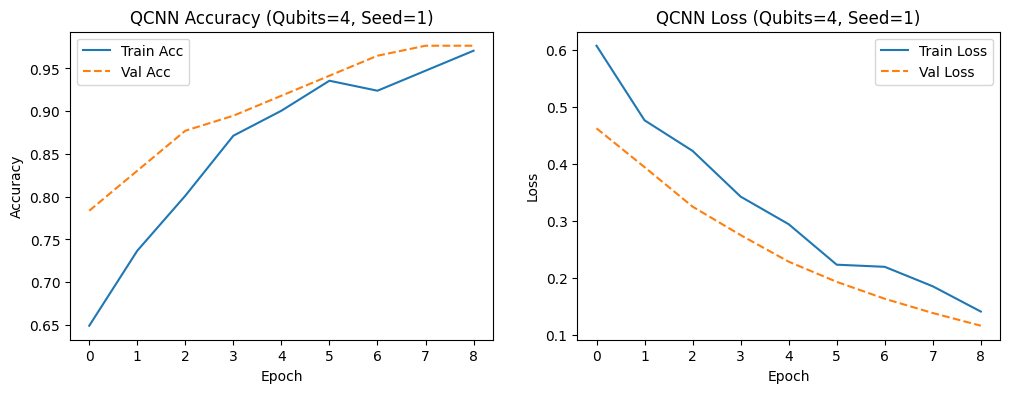


Running seed 2 for 4 qubits 
Epoch 1/9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 2s - 409ms/step - accuracy: 0.5906 - loss: 0.7087 - val_accuracy: 0.6959 - val_loss: 0.6335
Epoch 2/9
6/6 - 0s - 15ms/step - accuracy: 0.7193 - loss: 0.5836 - val_accuracy: 0.7836 - val_loss: 0.4613
Epoch 3/9
6/6 - 0s - 15ms/step - accuracy: 0.7895 - loss: 0.4543 - val_accuracy: 0.8304 - val_loss: 0.3953
Epoch 4/9
6/6 - 0s - 15ms/step - accuracy: 0.8480 - loss: 0.3931 - val_accuracy: 0.8713 - val_loss: 0.3522
Epoch 5/9
6/6 - 0s - 15ms/step - accuracy: 0.8421 - loss: 0.3457 - val_accuracy: 0.8947 - val_loss: 0.2945
Epoch 6/9
6/6 - 0s - 15ms/step - accuracy: 0.8889 - loss: 0.3054 - val_accuracy: 0.9064 - val_loss: 0.2610
Epoch 7/9
6/6 - 0s - 15ms/step - accuracy: 0.9006 - loss: 0.2691 - val_accuracy: 0.9240 - val_loss: 0.2257
Epoch 8/9
6/6 - 0s - 15ms/step - accuracy: 0.9064 - loss: 0.2548 - val_accuracy: 0.9474 - val_loss: 0.1933
Epoch 9/9
6/6 - 0s - 15ms/step - accuracy: 0.9298 - loss: 0.2160 - val_accuracy: 0.9649 - val_loss: 0.1708
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

Classif

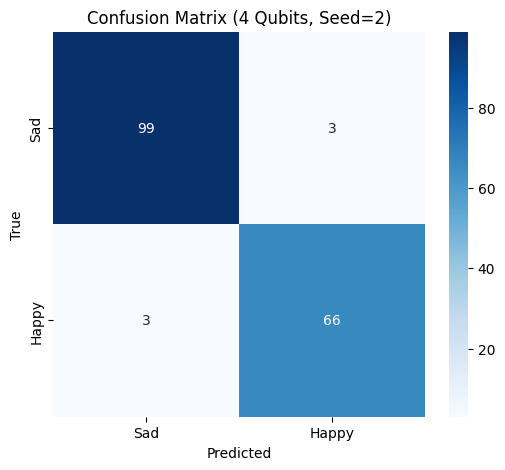

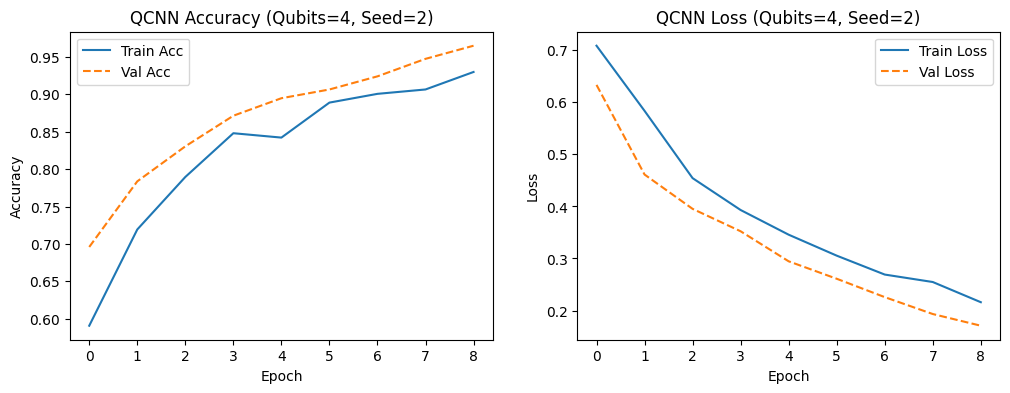


Running seed 3 for 4 qubits 
Epoch 1/9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 2s - 408ms/step - accuracy: 0.6316 - loss: 0.6380 - val_accuracy: 0.7602 - val_loss: 0.4688
Epoch 2/9
6/6 - 0s - 15ms/step - accuracy: 0.8070 - loss: 0.4573 - val_accuracy: 0.8538 - val_loss: 0.3482
Epoch 3/9
6/6 - 0s - 15ms/step - accuracy: 0.8538 - loss: 0.3614 - val_accuracy: 0.8947 - val_loss: 0.2796
Epoch 4/9
6/6 - 0s - 15ms/step - accuracy: 0.8889 - loss: 0.2853 - val_accuracy: 0.9240 - val_loss: 0.2266
Epoch 5/9
6/6 - 0s - 14ms/step - accuracy: 0.9357 - loss: 0.2458 - val_accuracy: 0.9474 - val_loss: 0.1856
Epoch 6/9
6/6 - 0s - 15ms/step - accuracy: 0.9064 - loss: 0.2091 - val_accuracy: 0.9591 - val_loss: 0.1653
Epoch 7/9
6/6 - 0s - 17ms/step - accuracy: 0.9532 - loss: 0.1796 - val_accuracy: 0.9708 - val_loss: 0.1360
Epoch 8/9
6/6 - 0s - 18ms/step - accuracy: 0.9649 - loss: 0.1436 - val_accuracy: 0.9942 - val_loss: 0.1229
Epoch 9/9
6/6 - 0s - 16ms/step - accuracy: 0.9766 - loss: 0.1407 - val_accuracy: 0.9883 - val_loss: 0.0901
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Classif

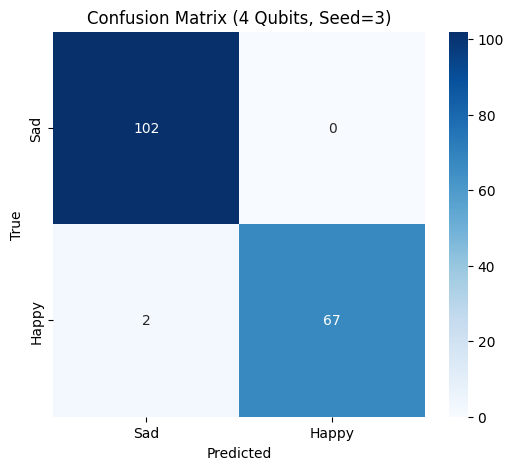

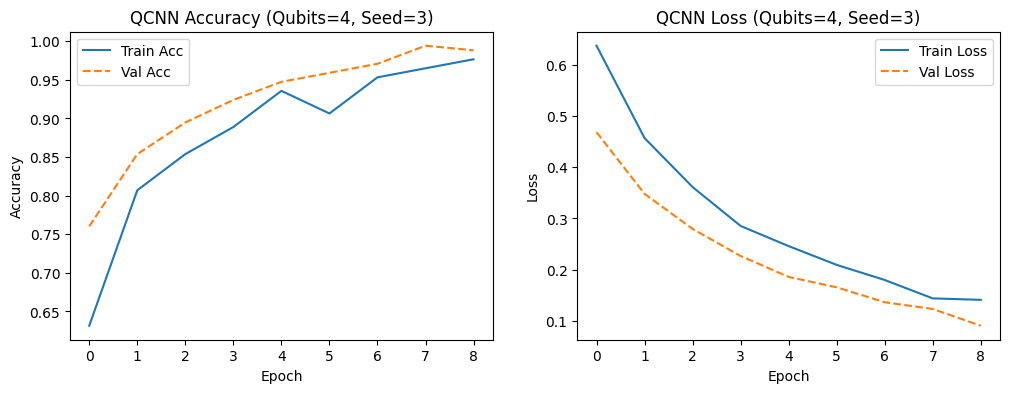


Running seed 4 for 4 qubits 
Epoch 1/9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 2s - 411ms/step - accuracy: 0.6199 - loss: 0.6937 - val_accuracy: 0.7661 - val_loss: 0.5066
Epoch 2/9
6/6 - 0s - 15ms/step - accuracy: 0.7836 - loss: 0.4939 - val_accuracy: 0.8304 - val_loss: 0.4138
Epoch 3/9
6/6 - 0s - 15ms/step - accuracy: 0.8070 - loss: 0.4260 - val_accuracy: 0.8889 - val_loss: 0.3636
Epoch 4/9
6/6 - 0s - 15ms/step - accuracy: 0.8538 - loss: 0.3692 - val_accuracy: 0.8655 - val_loss: 0.3249
Epoch 5/9
6/6 - 0s - 14ms/step - accuracy: 0.8772 - loss: 0.3250 - val_accuracy: 0.9006 - val_loss: 0.2751
Epoch 6/9
6/6 - 0s - 15ms/step - accuracy: 0.9006 - loss: 0.2843 - val_accuracy: 0.9415 - val_loss: 0.2377
Epoch 7/9
6/6 - 0s - 15ms/step - accuracy: 0.8947 - loss: 0.2649 - val_accuracy: 0.9415 - val_loss: 0.2036
Epoch 8/9
6/6 - 0s - 15ms/step - accuracy: 0.9357 - loss: 0.2274 - val_accuracy: 0.9532 - val_loss: 0.1767
Epoch 9/9
6/6 - 0s - 14ms/step - accuracy: 0.9532 - loss: 0.1887 - val_accuracy: 0.9708 - val_loss: 0.1535
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

Classif

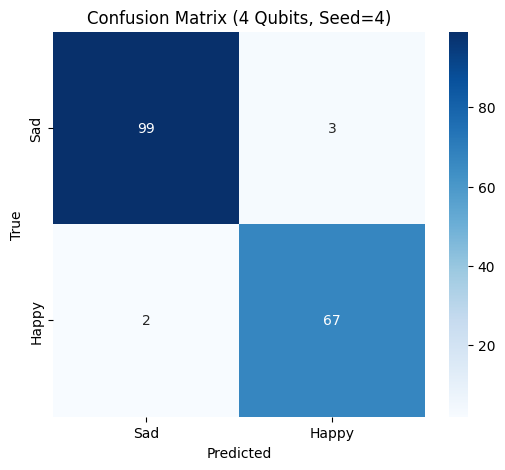

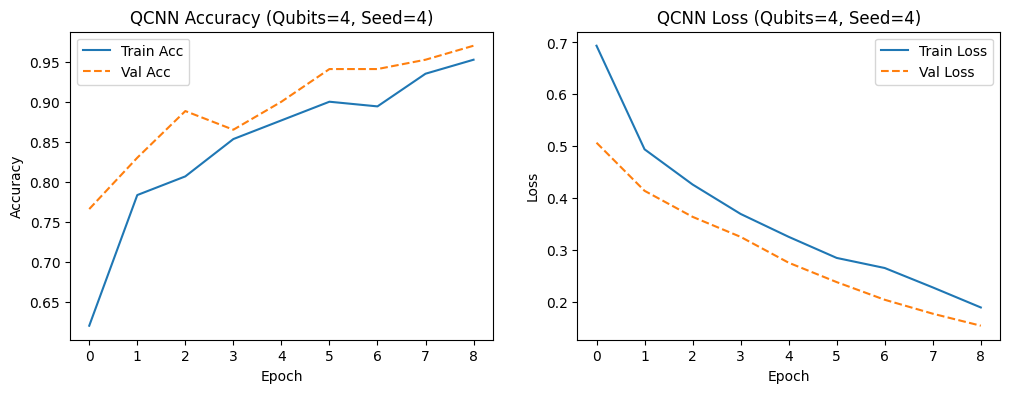


Summary for 4 Qubits:
  Accuracy : 0.9766 ± 0.0083 (95% CI: [0.9651, 0.9881])
  AUC      : 0.9973 ± 0.0025 (95% CI: [0.9938, 1.0008])
  Macro F1 : 0.9757 ± 0.0086 (95% CI: [0.9638, 0.9876])
Running experiments for 6 Qubits

Running seed 0 for 6 qubits 
Epoch 1/9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 3s - 461ms/step - accuracy: 0.6550 - loss: 0.7016 - val_accuracy: 0.7544 - val_loss: 0.5058
Epoch 2/9
6/6 - 0s - 15ms/step - accuracy: 0.7836 - loss: 0.4644 - val_accuracy: 0.8070 - val_loss: 0.4206
Epoch 3/9
6/6 - 0s - 15ms/step - accuracy: 0.8129 - loss: 0.3948 - val_accuracy: 0.8655 - val_loss: 0.3481
Epoch 4/9
6/6 - 0s - 15ms/step - accuracy: 0.8889 - loss: 0.3412 - val_accuracy: 0.8538 - val_loss: 0.3138
Epoch 5/9
6/6 - 0s - 15ms/step - accuracy: 0.8655 - loss: 0.3006 - val_accuracy: 0.9240 - val_loss: 0.2493
Epoch 6/9
6/6 - 0s - 15ms/step - accuracy: 0.9006 - loss: 0.2646 - val_accuracy: 0.9240 - val_loss: 0.2188
Epoch 7/9
6/6 - 0s - 15ms/step - accuracy: 0.9415 - loss: 0.2326 - val_accuracy: 0.9766 - val_loss: 0.1792
Epoch 8/9
6/6 - 0s - 15ms/step - accuracy: 0.9415 - loss: 0.1902 - val_accuracy: 0.9474 - val_loss: 0.1543
Epoch 9/9
6/6 - 0s - 15ms/step - accuracy: 0.9240 - loss: 0.2008 - val_accuracy: 0.9942 - val_loss: 0.1261
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

Classif

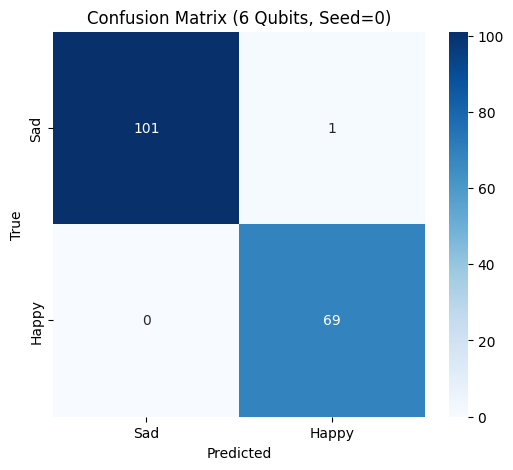

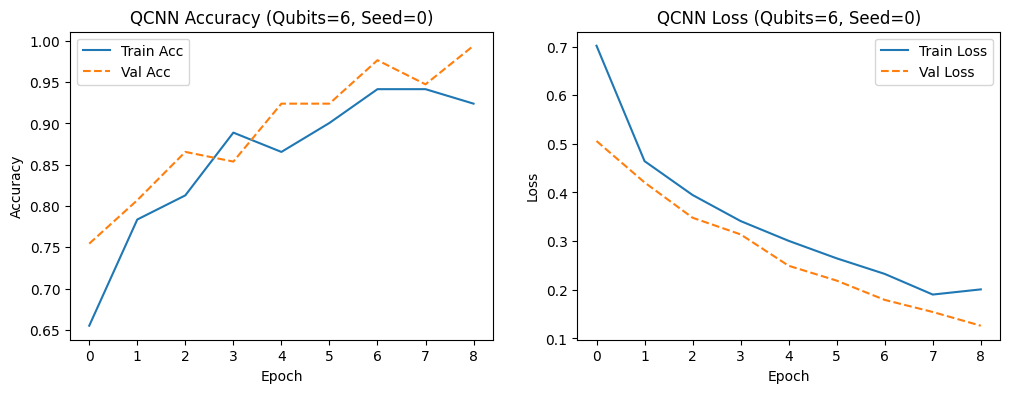


Running seed 1 for 6 qubits 
Epoch 1/9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 2s - 404ms/step - accuracy: 0.6140 - loss: 0.6643 - val_accuracy: 0.7310 - val_loss: 0.5162
Epoch 2/9
6/6 - 0s - 15ms/step - accuracy: 0.7485 - loss: 0.5396 - val_accuracy: 0.8246 - val_loss: 0.3997
Epoch 3/9
6/6 - 0s - 15ms/step - accuracy: 0.8246 - loss: 0.3993 - val_accuracy: 0.8304 - val_loss: 0.3516
Epoch 4/9
6/6 - 0s - 15ms/step - accuracy: 0.8070 - loss: 0.4022 - val_accuracy: 0.8889 - val_loss: 0.2960
Epoch 5/9
6/6 - 0s - 15ms/step - accuracy: 0.8889 - loss: 0.3066 - val_accuracy: 0.9123 - val_loss: 0.2514
Epoch 6/9
6/6 - 0s - 15ms/step - accuracy: 0.8947 - loss: 0.2724 - val_accuracy: 0.9123 - val_loss: 0.2171
Epoch 7/9
6/6 - 0s - 15ms/step - accuracy: 0.8772 - loss: 0.2515 - val_accuracy: 0.9766 - val_loss: 0.1794
Epoch 8/9
6/6 - 0s - 15ms/step - accuracy: 0.9298 - loss: 0.1911 - val_accuracy: 0.9766 - val_loss: 0.1499
Epoch 9/9
6/6 - 0s - 15ms/step - accuracy: 0.9591 - loss: 0.1735 - val_accuracy: 0.9825 - val_loss: 0.1285
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

Classif

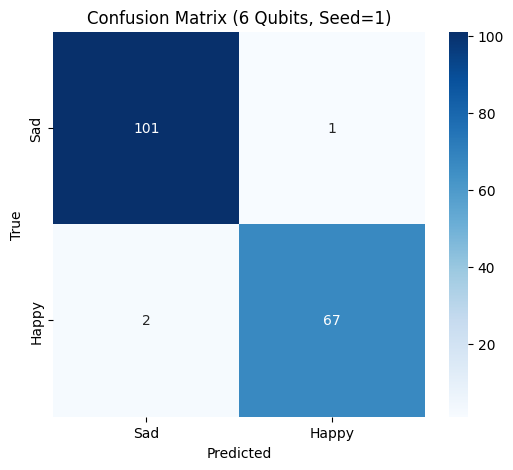

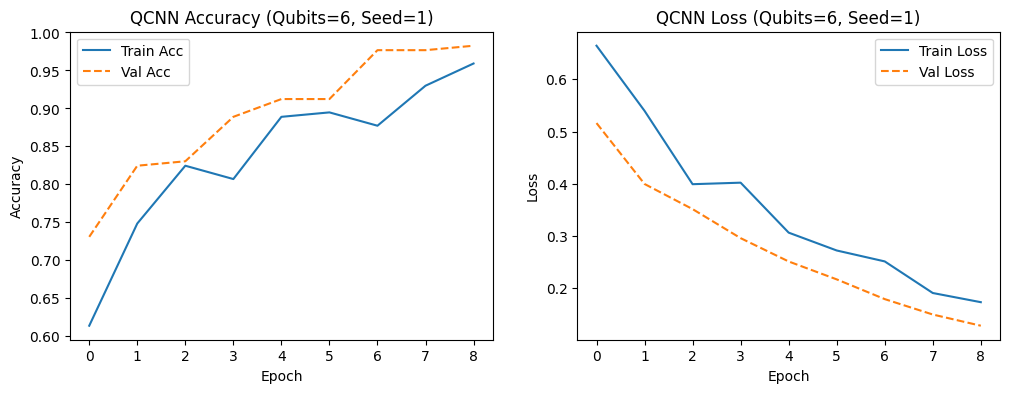


Running seed 2 for 6 qubits 
Epoch 1/9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 2s - 406ms/step - accuracy: 0.6257 - loss: 0.8175 - val_accuracy: 0.4561 - val_loss: 0.7163
Epoch 2/9
6/6 - 0s - 15ms/step - accuracy: 0.6374 - loss: 0.6503 - val_accuracy: 0.7485 - val_loss: 0.4985
Epoch 3/9
6/6 - 0s - 15ms/step - accuracy: 0.7251 - loss: 0.5138 - val_accuracy: 0.7602 - val_loss: 0.4474
Epoch 4/9
6/6 - 0s - 15ms/step - accuracy: 0.8012 - loss: 0.4452 - val_accuracy: 0.8830 - val_loss: 0.4047
Epoch 5/9
6/6 - 0s - 15ms/step - accuracy: 0.8538 - loss: 0.4079 - val_accuracy: 0.8713 - val_loss: 0.3497
Epoch 6/9
6/6 - 0s - 15ms/step - accuracy: 0.8363 - loss: 0.3735 - val_accuracy: 0.9006 - val_loss: 0.3038
Epoch 7/9
6/6 - 0s - 15ms/step - accuracy: 0.8596 - loss: 0.3175 - val_accuracy: 0.9240 - val_loss: 0.2627
Epoch 8/9
6/6 - 0s - 15ms/step - accuracy: 0.9298 - loss: 0.2757 - val_accuracy: 0.9415 - val_loss: 0.2222
Epoch 9/9
6/6 - 0s - 15ms/step - accuracy: 0.9415 - loss: 0.2216 - val_accuracy: 0.9708 - val_loss: 0.1952
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Classif

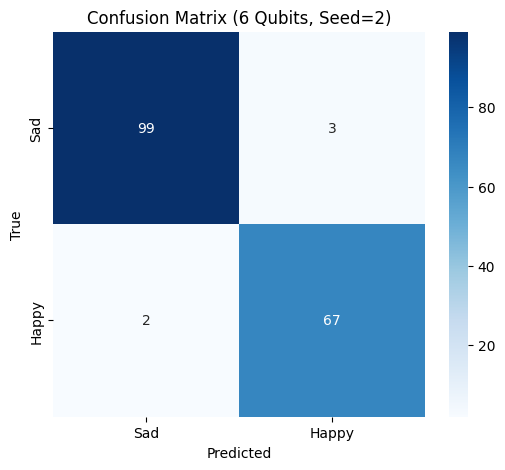

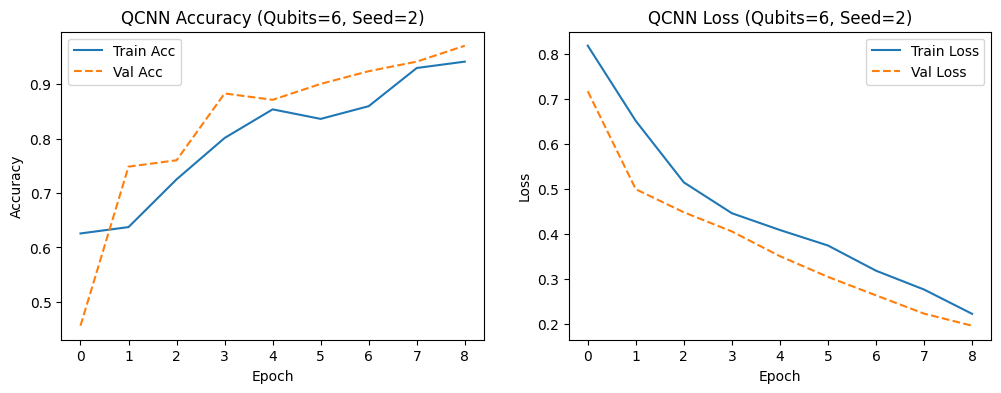


Running seed 3 for 6 qubits 
Epoch 1/9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 2s - 415ms/step - accuracy: 0.7018 - loss: 0.6865 - val_accuracy: 0.5906 - val_loss: 0.6735
Epoch 2/9
6/6 - 0s - 15ms/step - accuracy: 0.6608 - loss: 0.6037 - val_accuracy: 0.7427 - val_loss: 0.4781
Epoch 3/9
6/6 - 0s - 15ms/step - accuracy: 0.7953 - loss: 0.4214 - val_accuracy: 0.8713 - val_loss: 0.3741
Epoch 4/9
6/6 - 0s - 16ms/step - accuracy: 0.8596 - loss: 0.3995 - val_accuracy: 0.8772 - val_loss: 0.3043
Epoch 5/9
6/6 - 0s - 15ms/step - accuracy: 0.8480 - loss: 0.3256 - val_accuracy: 0.9006 - val_loss: 0.2592
Epoch 6/9
6/6 - 0s - 15ms/step - accuracy: 0.9181 - loss: 0.2628 - val_accuracy: 0.9357 - val_loss: 0.2229
Epoch 7/9
6/6 - 0s - 15ms/step - accuracy: 0.9064 - loss: 0.2439 - val_accuracy: 0.9474 - val_loss: 0.1864
Epoch 8/9
6/6 - 0s - 15ms/step - accuracy: 0.9474 - loss: 0.2018 - val_accuracy: 0.9649 - val_loss: 0.1604
Epoch 9/9
6/6 - 0s - 15ms/step - accuracy: 0.9298 - loss: 0.1845 - val_accuracy: 0.9883 - val_loss: 0.1348
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

Classif

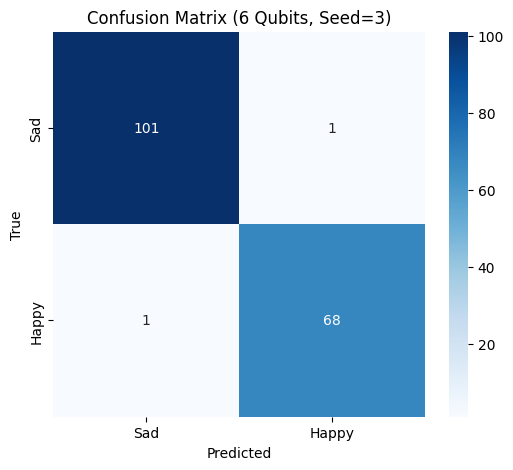

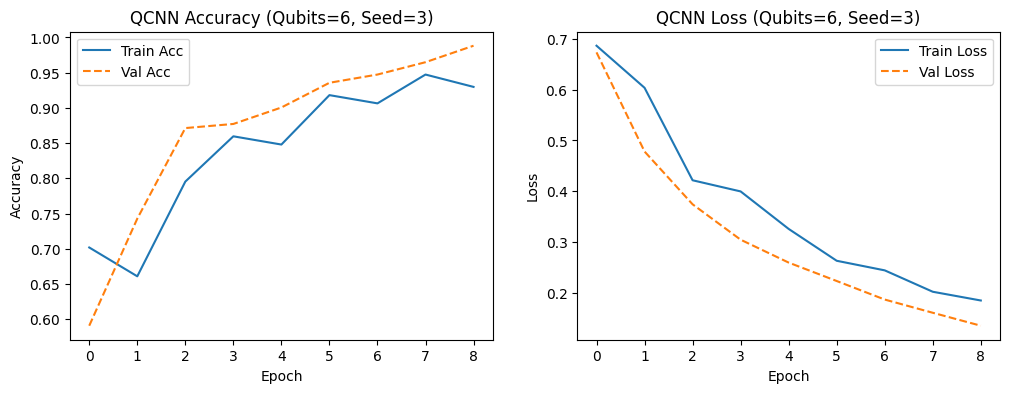


Running seed 4 for 6 qubits 
Epoch 1/9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 3s - 424ms/step - accuracy: 0.5673 - loss: 0.7269 - val_accuracy: 0.7544 - val_loss: 0.4884
Epoch 2/9
6/6 - 0s - 15ms/step - accuracy: 0.7602 - loss: 0.5046 - val_accuracy: 0.7836 - val_loss: 0.4448
Epoch 3/9
6/6 - 0s - 15ms/step - accuracy: 0.8012 - loss: 0.4447 - val_accuracy: 0.8713 - val_loss: 0.3715
Epoch 4/9
6/6 - 0s - 18ms/step - accuracy: 0.8421 - loss: 0.3690 - val_accuracy: 0.8830 - val_loss: 0.3175
Epoch 5/9
6/6 - 0s - 15ms/step - accuracy: 0.8889 - loss: 0.3324 - val_accuracy: 0.9298 - val_loss: 0.2842
Epoch 6/9
6/6 - 0s - 15ms/step - accuracy: 0.9006 - loss: 0.2895 - val_accuracy: 0.9064 - val_loss: 0.2385
Epoch 7/9
6/6 - 0s - 15ms/step - accuracy: 0.8889 - loss: 0.2719 - val_accuracy: 0.9708 - val_loss: 0.1984
Epoch 8/9
6/6 - 0s - 15ms/step - accuracy: 0.9357 - loss: 0.2273 - val_accuracy: 0.9825 - val_loss: 0.1667
Epoch 9/9
6/6 - 0s - 15ms/step - accuracy: 0.9591 - loss: 0.1757 - val_accuracy: 0.9825 - val_loss: 0.1430
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

Classif

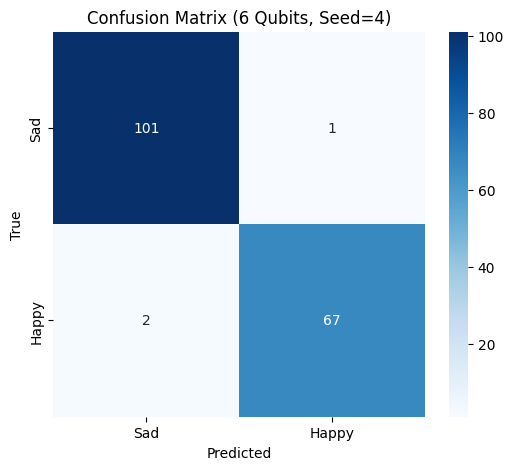

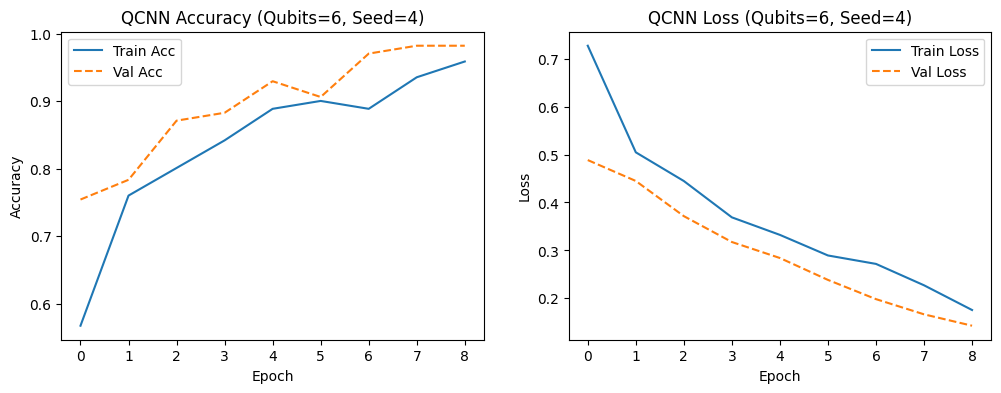


Summary for 6 Qubits:
  Accuracy : 0.9836 ± 0.0078 (95% CI: [0.9729, 0.9944])
  AUC      : 0.9982 ± 0.0018 (95% CI: [0.9957, 1.0007])
  Macro F1 : 0.9830 ± 0.0080 (95% CI: [0.9718, 0.9942])
Running experiments for 8 Qubits

Running seed 0 for 8 qubits 
Epoch 1/9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 3s - 487ms/step - accuracy: 0.6725 - loss: 0.6760 - val_accuracy: 0.8012 - val_loss: 0.4441
Epoch 2/9
6/6 - 0s - 16ms/step - accuracy: 0.7427 - loss: 0.4939 - val_accuracy: 0.8889 - val_loss: 0.3667
Epoch 3/9
6/6 - 0s - 15ms/step - accuracy: 0.8187 - loss: 0.3988 - val_accuracy: 0.8480 - val_loss: 0.3242
Epoch 4/9
6/6 - 0s - 15ms/step - accuracy: 0.8480 - loss: 0.3349 - val_accuracy: 0.9064 - val_loss: 0.2586
Epoch 5/9
6/6 - 0s - 18ms/step - accuracy: 0.8947 - loss: 0.2470 - val_accuracy: 0.9357 - val_loss: 0.2161
Epoch 6/9
6/6 - 0s - 15ms/step - accuracy: 0.9181 - loss: 0.2430 - val_accuracy: 0.9474 - val_loss: 0.1738
Epoch 7/9
6/6 - 0s - 15ms/step - accuracy: 0.9415 - loss: 0.1860 - val_accuracy: 0.9825 - val_loss: 0.1416
Epoch 8/9
6/6 - 0s - 15ms/step - accuracy: 0.9298 - loss: 0.1658 - val_accuracy: 0.9825 - val_loss: 0.1137
Epoch 9/9
6/6 - 0s - 15ms/step - accuracy: 0.9766 - loss: 0.1232 - val_accuracy: 1.0000 - val_loss: 0.0896
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

Classif

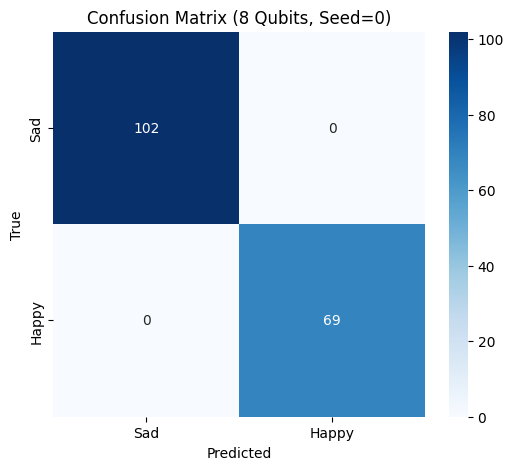

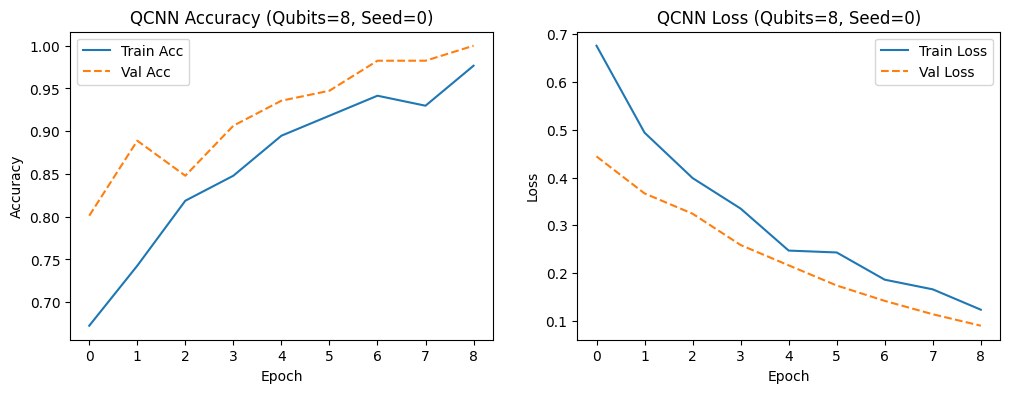


Running seed 1 for 8 qubits 
Epoch 1/9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 2s - 408ms/step - accuracy: 0.6140 - loss: 0.6856 - val_accuracy: 0.7193 - val_loss: 0.5807
Epoch 2/9
6/6 - 0s - 15ms/step - accuracy: 0.7251 - loss: 0.6535 - val_accuracy: 0.8187 - val_loss: 0.4138
Epoch 3/9
6/6 - 0s - 15ms/step - accuracy: 0.8363 - loss: 0.4217 - val_accuracy: 0.8538 - val_loss: 0.3392
Epoch 4/9
6/6 - 0s - 15ms/step - accuracy: 0.8070 - loss: 0.4145 - val_accuracy: 0.8830 - val_loss: 0.2779
Epoch 5/9
6/6 - 0s - 15ms/step - accuracy: 0.9006 - loss: 0.2768 - val_accuracy: 0.9357 - val_loss: 0.2333
Epoch 6/9
6/6 - 0s - 15ms/step - accuracy: 0.8947 - loss: 0.2380 - val_accuracy: 0.9298 - val_loss: 0.1843
Epoch 7/9
6/6 - 0s - 15ms/step - accuracy: 0.8772 - loss: 0.2358 - val_accuracy: 0.9591 - val_loss: 0.1627
Epoch 8/9
6/6 - 0s - 15ms/step - accuracy: 0.9532 - loss: 0.1743 - val_accuracy: 0.9883 - val_loss: 0.1293
Epoch 9/9
6/6 - 0s - 15ms/step - accuracy: 0.9591 - loss: 0.1542 - val_accuracy: 0.9883 - val_loss: 0.1053
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

Classif

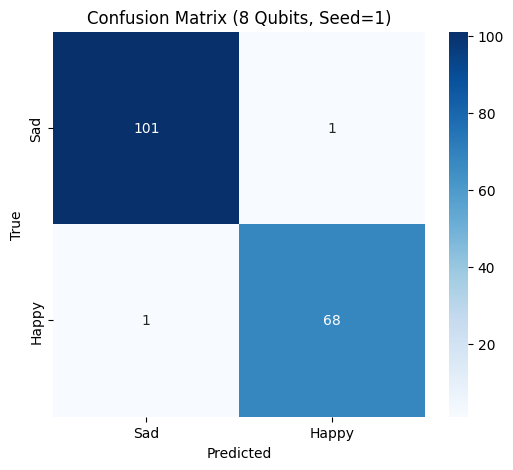

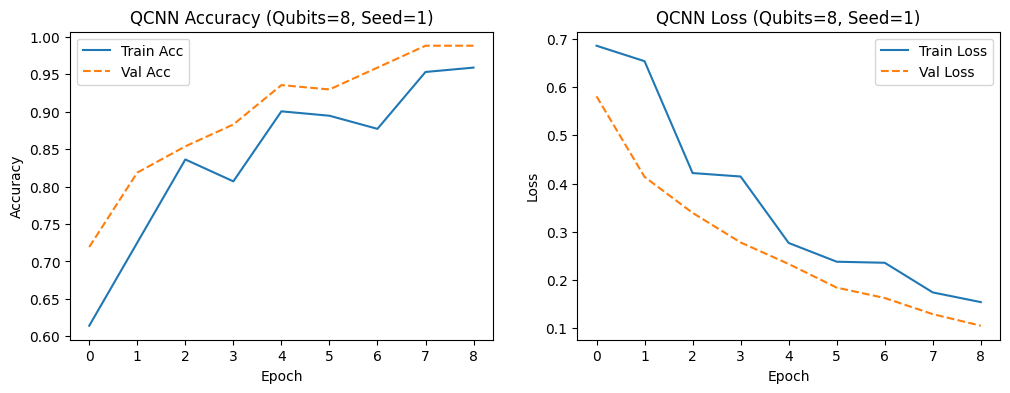


Running seed 2 for 8 qubits 
Epoch 1/9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 3s - 426ms/step - accuracy: 0.5848 - loss: 0.8708 - val_accuracy: 0.6257 - val_loss: 0.6238
Epoch 2/9
6/6 - 0s - 15ms/step - accuracy: 0.6491 - loss: 0.6079 - val_accuracy: 0.7661 - val_loss: 0.5117
Epoch 3/9
6/6 - 0s - 15ms/step - accuracy: 0.7193 - loss: 0.5103 - val_accuracy: 0.7719 - val_loss: 0.4462
Epoch 4/9
6/6 - 0s - 15ms/step - accuracy: 0.7836 - loss: 0.4325 - val_accuracy: 0.8304 - val_loss: 0.4032
Epoch 5/9
6/6 - 0s - 15ms/step - accuracy: 0.8070 - loss: 0.4002 - val_accuracy: 0.8421 - val_loss: 0.3478
Epoch 6/9
6/6 - 0s - 16ms/step - accuracy: 0.8421 - loss: 0.3679 - val_accuracy: 0.8830 - val_loss: 0.3065
Epoch 7/9
6/6 - 0s - 15ms/step - accuracy: 0.8830 - loss: 0.3271 - val_accuracy: 0.9298 - val_loss: 0.2772
Epoch 8/9
6/6 - 0s - 15ms/step - accuracy: 0.9064 - loss: 0.2823 - val_accuracy: 0.9240 - val_loss: 0.2378
Epoch 9/9
6/6 - 0s - 15ms/step - accuracy: 0.8889 - loss: 0.2542 - val_accuracy: 0.9357 - val_loss: 0.2118
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

Classif

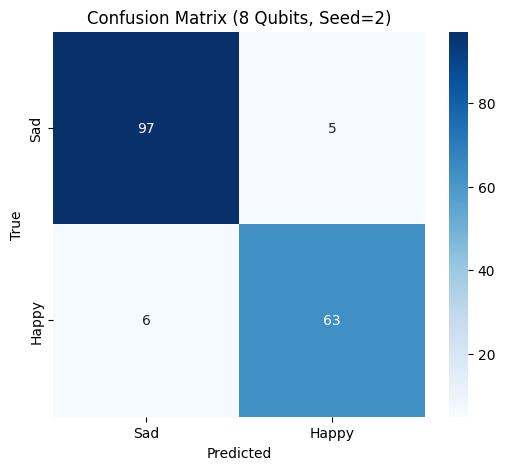

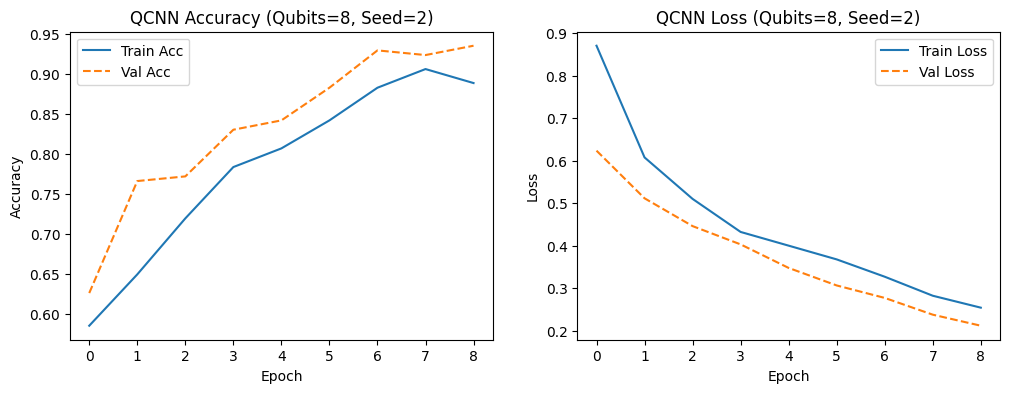


Running seed 3 for 8 qubits 
Epoch 1/9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 3s - 422ms/step - accuracy: 0.6023 - loss: 0.7158 - val_accuracy: 0.7193 - val_loss: 0.5455
Epoch 2/9
6/6 - 0s - 16ms/step - accuracy: 0.7602 - loss: 0.5404 - val_accuracy: 0.7895 - val_loss: 0.4161
Epoch 3/9
6/6 - 0s - 15ms/step - accuracy: 0.7836 - loss: 0.4175 - val_accuracy: 0.8947 - val_loss: 0.3408
Epoch 4/9
6/6 - 0s - 15ms/step - accuracy: 0.8538 - loss: 0.3389 - val_accuracy: 0.8889 - val_loss: 0.2919
Epoch 5/9
6/6 - 0s - 15ms/step - accuracy: 0.8772 - loss: 0.2878 - val_accuracy: 0.9298 - val_loss: 0.2385
Epoch 6/9
6/6 - 0s - 15ms/step - accuracy: 0.8889 - loss: 0.2740 - val_accuracy: 0.9474 - val_loss: 0.1889
Epoch 7/9
6/6 - 0s - 15ms/step - accuracy: 0.9181 - loss: 0.2083 - val_accuracy: 0.9649 - val_loss: 0.1597
Epoch 8/9
6/6 - 0s - 15ms/step - accuracy: 0.9474 - loss: 0.1898 - val_accuracy: 0.9942 - val_loss: 0.1261
Epoch 9/9
6/6 - 0s - 15ms/step - accuracy: 0.9708 - loss: 0.1451 - val_accuracy: 0.9942 - val_loss: 0.1020
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

Classif

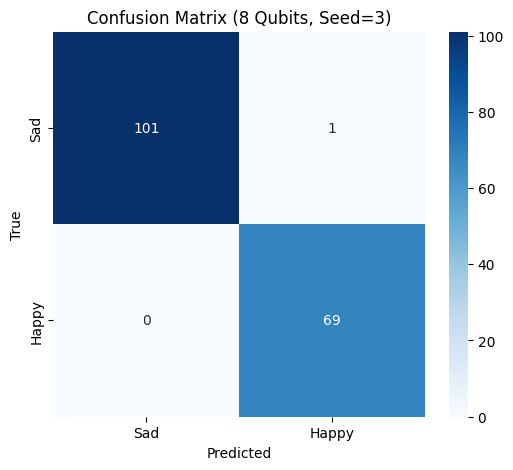

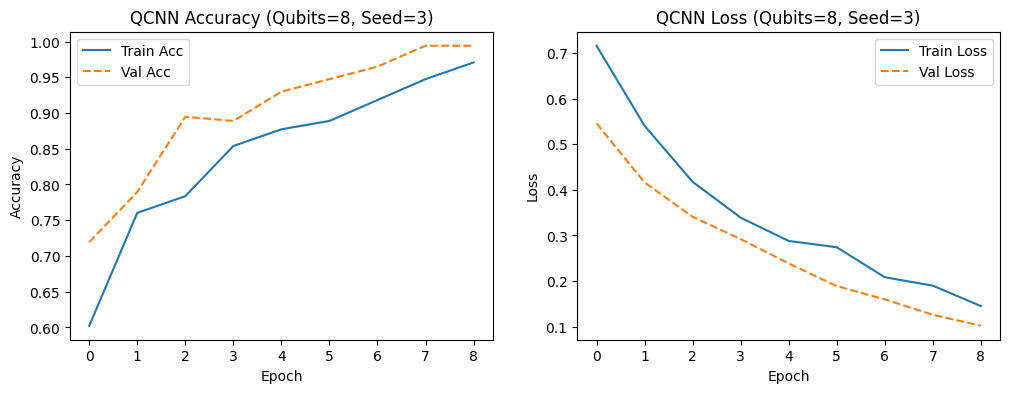


Running seed 4 for 8 qubits 
Epoch 1/9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 2s - 404ms/step - accuracy: 0.5614 - loss: 0.7261 - val_accuracy: 0.7076 - val_loss: 0.5183
Epoch 2/9
6/6 - 0s - 15ms/step - accuracy: 0.7135 - loss: 0.5349 - val_accuracy: 0.8187 - val_loss: 0.4720
Epoch 3/9
6/6 - 0s - 16ms/step - accuracy: 0.8538 - loss: 0.4583 - val_accuracy: 0.8713 - val_loss: 0.3767
Epoch 4/9
6/6 - 0s - 17ms/step - accuracy: 0.8596 - loss: 0.3614 - val_accuracy: 0.8713 - val_loss: 0.3288
Epoch 5/9
6/6 - 0s - 15ms/step - accuracy: 0.8480 - loss: 0.3426 - val_accuracy: 0.9064 - val_loss: 0.2873
Epoch 6/9
6/6 - 0s - 15ms/step - accuracy: 0.8830 - loss: 0.3095 - val_accuracy: 0.8947 - val_loss: 0.2430
Epoch 7/9
6/6 - 0s - 15ms/step - accuracy: 0.9006 - loss: 0.2531 - val_accuracy: 0.9591 - val_loss: 0.2040
Epoch 8/9
6/6 - 0s - 15ms/step - accuracy: 0.9240 - loss: 0.2292 - val_accuracy: 0.9591 - val_loss: 0.1684
Epoch 9/9
6/6 - 0s - 15ms/step - accuracy: 0.9474 - loss: 0.1896 - val_accuracy: 0.9649 - val_loss: 0.1411
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

Classif

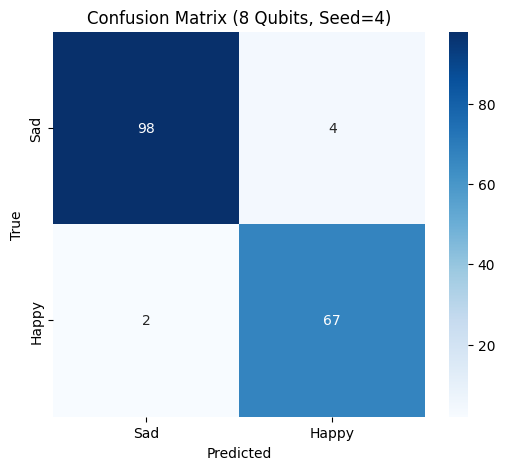

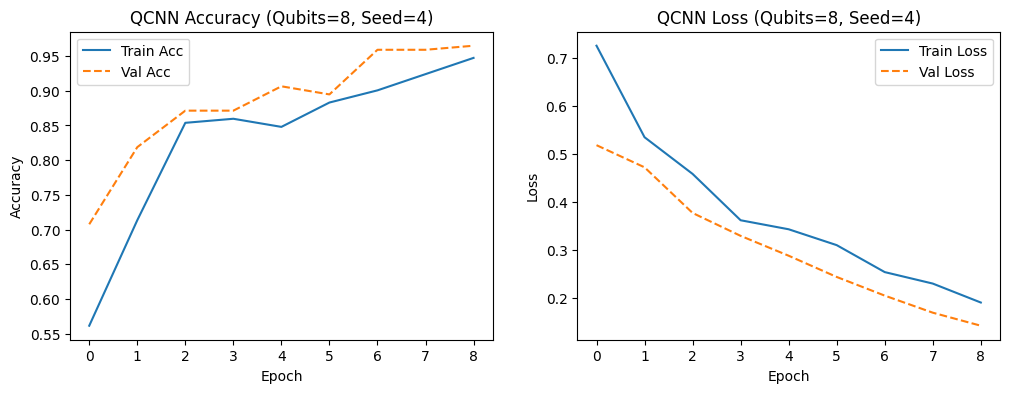


Summary for 8 Qubits:
  Accuracy : 0.9766 ± 0.0237 (95% CI: [0.9437, 1.0095])
  AUC      : 0.9965 ± 0.0060 (95% CI: [0.9882, 1.0047])
  Macro F1 : 0.9757 ± 0.0246 (95% CI: [0.9415, 1.0099])


In [3]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane.templates import RandomLayers
import scipy.stats as st
from collections import Counter


EMOTIONS = ['Sad', 'Happy']   # Only two classes

qubit_patch_shapes = {
    4: (2, 2),
    6: (3, 2),
    8: (4, 2),
}

n_epochs = 9
seeds = [0, 1, 2, 3, 4]
qubit_list = [4, 6, 8]


print("Train set class counts:")
train_counts = Counter(train_labels)
for i, cls in enumerate(EMOTIONS):
    print(f"  {cls:10s}: {train_counts.get(i, 0)} samples")

print("\nTest set class counts:")
test_counts = Counter(test_labels)
for i, cls in enumerate(EMOTIONS):
    print(f"  {cls:10s}: {test_counts.get(i, 0)} samples")


def create_circuit(n_qubits, n_layers=3):
    dev = qml.device("default.qubit", wires=n_qubits)
    rand_params = np.random.uniform(high=2*np.pi, size=(n_layers, n_qubits))

    @qml.qnode(dev)
    def circuit(phi):
        for j in range(n_qubits):
            qml.RY(np.pi * phi[j], wires=j)
        RandomLayers(rand_params, wires=range(n_qubits))
        return [qml.expval(qml.PauliZ(j)) for j in range(n_qubits)]
    
    return circuit


def quanv(image, circuit, patch_h, patch_w):
    out_h = (image.shape[0] - patch_h) // 2 + 1
    out_w = (image.shape[1] - patch_w) // 2 + 1
    n_qubits = patch_h * patch_w
    out = np.zeros((out_h, out_w, n_qubits))

    for j in range(0, image.shape[0] - patch_h + 1, 2):
        for k in range(0, image.shape[1] - patch_w + 1, 2):
            patch = image[j:j+patch_h, k:k+patch_w, 0].flatten()
            out[j//2, k//2, :] = circuit(patch)
    return out


for q in qubit_list:
    print(f"Running experiments for {q} Qubits")

    # Initialize storage for results
    acc_list, auc_list, f1_list = [], [], []

    patch_h, patch_w = qubit_patch_shapes[q]
    circuit = create_circuit(q)

    # Run across all random seeds
    for seed in seeds:
        print(f"\nRunning seed {seed} for {q} qubits ")
        np.random.seed(seed)
        tf.random.set_seed(seed)

        # Quantum feature mapping
        q_train = np.array([quanv(img, circuit, patch_h, patch_w) for img in train_images])
        q_test = np.array([quanv(img, circuit, patch_h, patch_w) for img in test_images])

        # Classical NN on quantum features
        model = keras.Sequential([
            keras.layers.Flatten(input_shape=q_train.shape[1:]),
            keras.layers.Dense(64, activation='relu'),
            keras.layers.Dropout(0.3),
            keras.layers.Dense(1, activation='sigmoid')  # Binary classification
        ])
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        history = model.fit(q_train, train_labels,
                            validation_data=(q_test, test_labels),
                            epochs=n_epochs, batch_size=32, verbose=2)

        # Predictions
        y_pred_prob = model.predict(q_test).flatten()
        y_pred = (y_pred_prob > 0.5).astype(int)

        # Evaluation metrics
        auc = roc_auc_score(test_labels, y_pred_prob)
        macro_f1 = f1_score(test_labels, y_pred, average='macro')
        acc = np.mean(y_pred == test_labels)

        acc_list.append(acc)
        auc_list.append(auc)
        f1_list.append(macro_f1)

        # Classification Report
        print("\nClassification Report:")
        print(classification_report(test_labels, y_pred, target_names=EMOTIONS))

        # Confusion Matrix
        cm = confusion_matrix(test_labels, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=EMOTIONS, yticklabels=EMOTIONS)
        plt.title(f"Confusion Matrix ({q} Qubits, Seed={seed})")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()

        # Accuracy/Loss Curves
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(history.history['accuracy'], label='Train Acc')
        plt.plot(history.history['val_accuracy'], '--', label='Val Acc')
        plt.title(f"QCNN Accuracy (Qubits={q}, Seed={seed})")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'], label='Train Loss')
        plt.plot(history.history['val_loss'], '--', label='Val Loss')
        plt.title(f"QCNN Loss (Qubits={q}, Seed={seed})")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.show()

    # Compute summary statistics
    acc_arr, auc_arr, f1_arr = np.array(acc_list), np.array(auc_list), np.array(f1_list)

    mean_acc, std_acc = acc_arr.mean(), acc_arr.std()
    mean_auc, std_auc = auc_arr.mean(), auc_arr.std()
    mean_f1, std_f1 = f1_arr.mean(), f1_arr.std()

    ci_acc = st.t.interval(0.95, len(acc_arr)-1, loc=mean_acc, scale=st.sem(acc_arr))
    ci_auc = st.t.interval(0.95, len(auc_arr)-1, loc=mean_auc, scale=st.sem(auc_arr))
    ci_f1 = st.t.interval(0.95, len(f1_arr)-1, loc=mean_f1, scale=st.sem(f1_arr))

    print(f"\nSummary for {q} Qubits:")
    print(f"  Accuracy : {mean_acc:.4f} ± {std_acc:.4f} (95% CI: [{ci_acc[0]:.4f}, {ci_acc[1]:.4f}])")
    print(f"  AUC      : {mean_auc:.4f} ± {std_auc:.4f} (95% CI: [{ci_auc[0]:.4f}, {ci_auc[1]:.4f}])")
    print(f"  Macro F1 : {mean_f1:.4f} ± {std_f1:.4f} (95% CI: [{ci_f1[0]:.4f}, {ci_f1[1]:.4f}])")


Train set class counts:
  Sad       : 102 samples
  Happy     : 69 samples

Test set class counts:
  Sad       : 102 samples
  Happy     : 69 samples
Running experiments for 10 Qubits

Running seed 0 for 10 qubits 


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1762862101.331991      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1762862101.332784      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/9


I0000 00:00:1762862103.403540     123 service.cc:148] XLA service 0x7d2bbc002140 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762862103.404049     123 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1762862103.404070     123 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1762862103.608491     123 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1762862104.536527     123 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6/6 - 3s - 563ms/step - accuracy: 0.6608 - loss: 0.8553 - val_accuracy: 0.6667 - val_loss: 0.6198
Epoch 2/9
6/6 - 0s - 15ms/step - accuracy: 0.7485 - loss: 0.5721 - val_accuracy: 0.7836 - val_loss: 0.4340
Epoch 3/9
6/6 - 0s - 15ms/step - accuracy: 0.7427 - loss: 0.5394 - val_accuracy: 0.8421 - val_loss: 0.3800
Epoch 4/9
6/6 - 0s - 15ms/step - accuracy: 0.8363 - loss: 0.3865 - val_accuracy: 0.8421 - val_loss: 0.3408
Epoch 5/9
6/6 - 0s - 15ms/step - accuracy: 0.8713 - loss: 0.3174 - val_accuracy: 0.9006 - val_loss: 0.2934
Epoch 6/9
6/6 - 0s - 15ms/step - accuracy: 0.8655 - loss: 0.3289 - val_accuracy: 0.8889 - val_loss: 0.2546
Epoch 7/9
6/6 - 0s - 15ms/step - accuracy: 0.8947 - loss: 0.2717 - val_accuracy: 0.9415 - val_loss: 0.2124
Epoch 8/9
6/6 - 0s - 15ms/step - accuracy: 0.9298 - loss: 0.2118 - val_accuracy: 0.9474 - val_loss: 0.1886
Epoch 9/9
6/6 - 0s - 15ms/step - accuracy: 0.9474 - loss: 0.2030 - val_accuracy: 0.9766 - val_loss: 0.1584
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

Classif

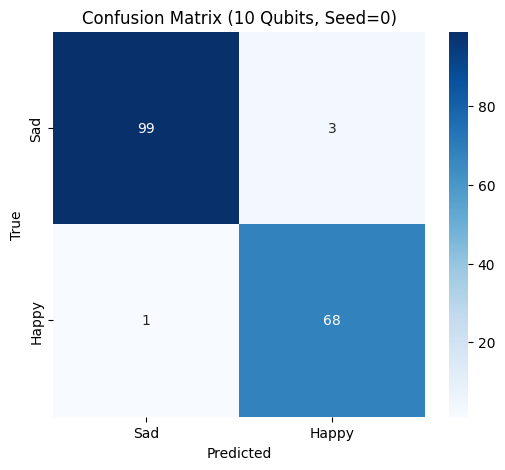

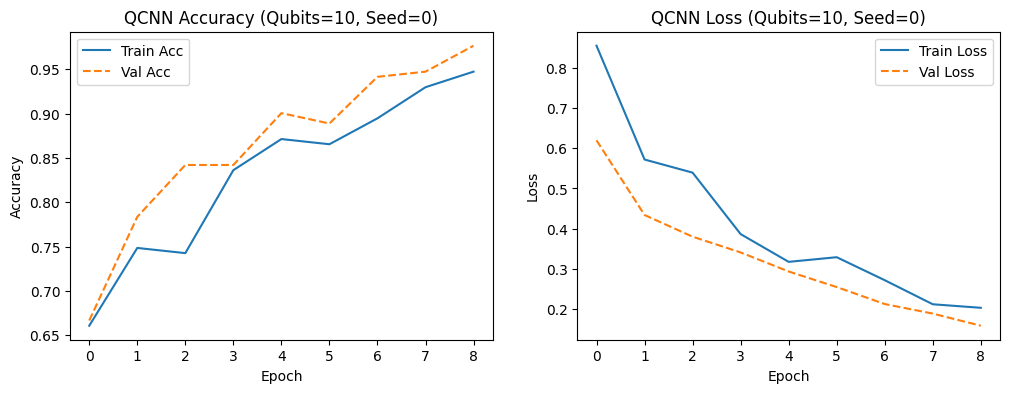


Running seed 1 for 10 qubits 
Epoch 1/9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 3s - 427ms/step - accuracy: 0.5263 - loss: 0.9260 - val_accuracy: 0.7485 - val_loss: 0.5156
Epoch 2/9
6/6 - 0s - 15ms/step - accuracy: 0.7018 - loss: 0.6870 - val_accuracy: 0.7485 - val_loss: 0.5004
Epoch 3/9
6/6 - 0s - 15ms/step - accuracy: 0.7310 - loss: 0.5345 - val_accuracy: 0.8421 - val_loss: 0.4146
Epoch 4/9
6/6 - 0s - 15ms/step - accuracy: 0.7544 - loss: 0.4896 - val_accuracy: 0.7485 - val_loss: 0.4284
Epoch 5/9
6/6 - 0s - 15ms/step - accuracy: 0.8070 - loss: 0.4125 - val_accuracy: 0.8596 - val_loss: 0.3539
Epoch 6/9
6/6 - 0s - 16ms/step - accuracy: 0.8596 - loss: 0.3779 - val_accuracy: 0.8655 - val_loss: 0.3261
Epoch 7/9
6/6 - 0s - 15ms/step - accuracy: 0.8187 - loss: 0.3549 - val_accuracy: 0.8713 - val_loss: 0.2911
Epoch 8/9
6/6 - 0s - 15ms/step - accuracy: 0.8772 - loss: 0.3086 - val_accuracy: 0.9240 - val_loss: 0.2537
Epoch 9/9
6/6 - 0s - 16ms/step - accuracy: 0.9006 - loss: 0.2793 - val_accuracy: 0.9357 - val_loss: 0.2250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Classif

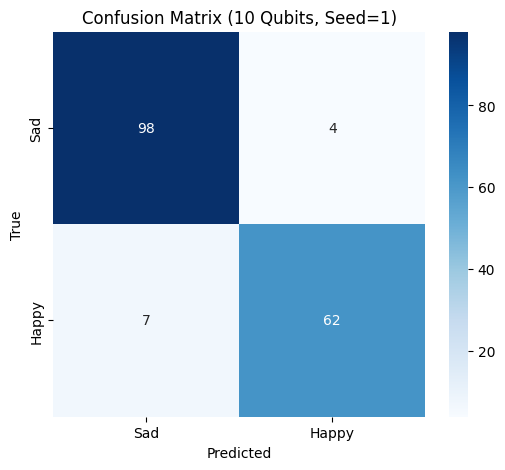

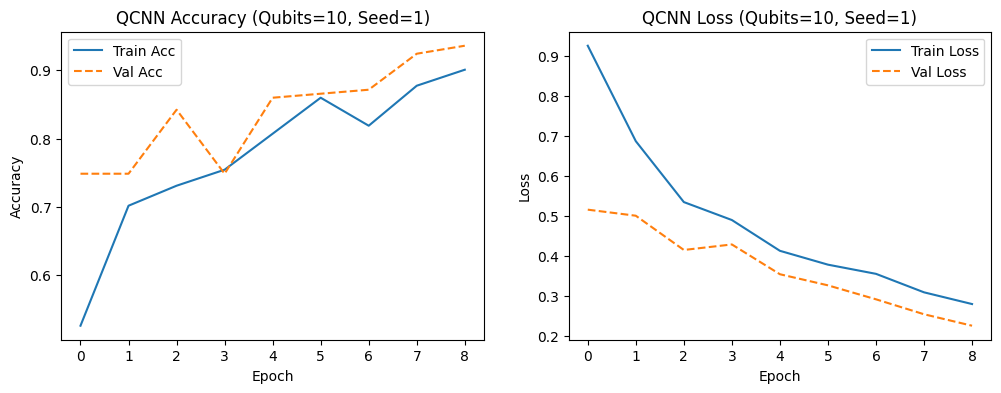


Running seed 2 for 10 qubits 
Epoch 1/9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 3s - 430ms/step - accuracy: 0.5906 - loss: 1.0826 - val_accuracy: 0.4678 - val_loss: 0.6789
Epoch 2/9
6/6 - 0s - 16ms/step - accuracy: 0.5965 - loss: 0.6630 - val_accuracy: 0.7193 - val_loss: 0.5660
Epoch 3/9
6/6 - 0s - 16ms/step - accuracy: 0.6784 - loss: 0.5943 - val_accuracy: 0.7193 - val_loss: 0.4964
Epoch 4/9
6/6 - 0s - 15ms/step - accuracy: 0.7193 - loss: 0.5218 - val_accuracy: 0.7895 - val_loss: 0.4452
Epoch 5/9
6/6 - 0s - 15ms/step - accuracy: 0.7661 - loss: 0.4839 - val_accuracy: 0.8538 - val_loss: 0.4110
Epoch 6/9
6/6 - 0s - 15ms/step - accuracy: 0.8187 - loss: 0.4280 - val_accuracy: 0.8480 - val_loss: 0.3823
Epoch 7/9
6/6 - 0s - 15ms/step - accuracy: 0.8129 - loss: 0.4142 - val_accuracy: 0.8889 - val_loss: 0.3600
Epoch 8/9
6/6 - 0s - 15ms/step - accuracy: 0.8713 - loss: 0.3696 - val_accuracy: 0.8947 - val_loss: 0.3207
Epoch 9/9
6/6 - 0s - 15ms/step - accuracy: 0.8538 - loss: 0.3483 - val_accuracy: 0.9006 - val_loss: 0.3000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

Classif

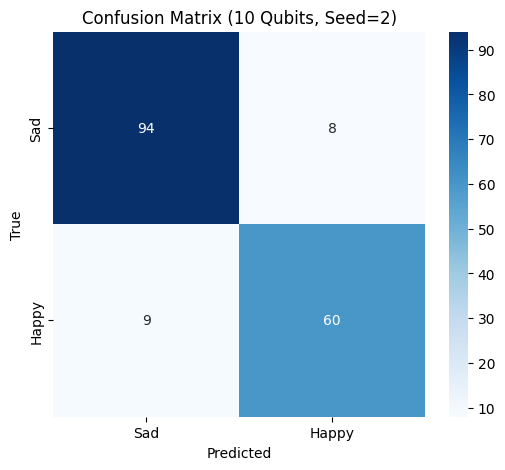

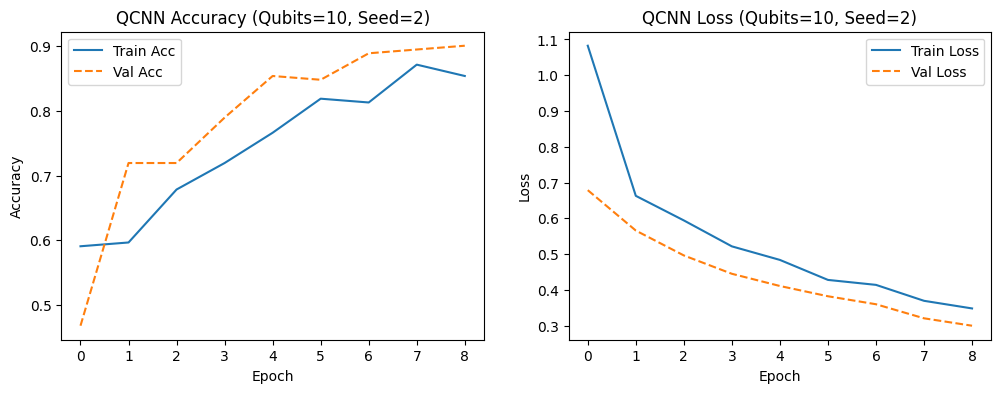


Running seed 3 for 10 qubits 
Epoch 1/9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 3s - 422ms/step - accuracy: 0.5614 - loss: 1.1792 - val_accuracy: 0.5380 - val_loss: 0.7040
Epoch 2/9
6/6 - 0s - 15ms/step - accuracy: 0.6433 - loss: 0.6644 - val_accuracy: 0.7193 - val_loss: 0.5282
Epoch 3/9
6/6 - 0s - 16ms/step - accuracy: 0.7368 - loss: 0.5158 - val_accuracy: 0.7661 - val_loss: 0.4613
Epoch 4/9
6/6 - 0s - 15ms/step - accuracy: 0.7544 - loss: 0.4732 - val_accuracy: 0.7895 - val_loss: 0.4315
Epoch 5/9
6/6 - 0s - 15ms/step - accuracy: 0.7602 - loss: 0.4376 - val_accuracy: 0.7836 - val_loss: 0.3968
Epoch 6/9
6/6 - 0s - 15ms/step - accuracy: 0.7719 - loss: 0.4129 - val_accuracy: 0.8538 - val_loss: 0.3530
Epoch 7/9
6/6 - 0s - 15ms/step - accuracy: 0.8070 - loss: 0.3735 - val_accuracy: 0.8421 - val_loss: 0.3364
Epoch 8/9
6/6 - 0s - 15ms/step - accuracy: 0.8421 - loss: 0.3365 - val_accuracy: 0.8538 - val_loss: 0.2994
Epoch 9/9
6/6 - 0s - 15ms/step - accuracy: 0.8363 - loss: 0.3149 - val_accuracy: 0.9064 - val_loss: 0.2663
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

Classif

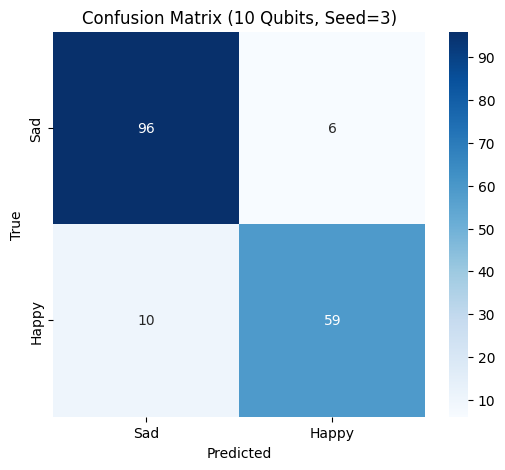

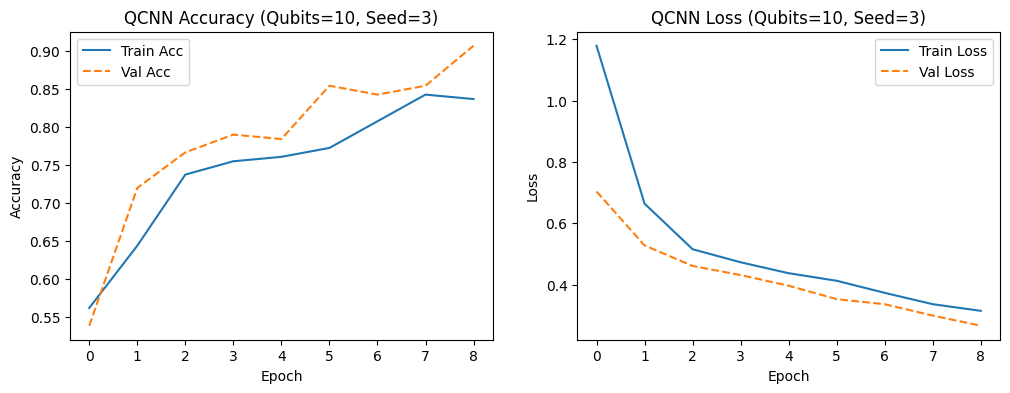


Running seed 4 for 10 qubits 
Epoch 1/9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 3s - 421ms/step - accuracy: 0.5088 - loss: 0.9338 - val_accuracy: 0.7602 - val_loss: 0.5281
Epoch 2/9
6/6 - 0s - 15ms/step - accuracy: 0.7427 - loss: 0.5146 - val_accuracy: 0.7135 - val_loss: 0.4753
Epoch 3/9
6/6 - 0s - 15ms/step - accuracy: 0.7836 - loss: 0.4756 - val_accuracy: 0.8480 - val_loss: 0.4271
Epoch 4/9
6/6 - 0s - 15ms/step - accuracy: 0.8012 - loss: 0.4132 - val_accuracy: 0.8304 - val_loss: 0.3703
Epoch 5/9
6/6 - 0s - 15ms/step - accuracy: 0.8070 - loss: 0.3754 - val_accuracy: 0.8889 - val_loss: 0.3287
Epoch 6/9
6/6 - 0s - 15ms/step - accuracy: 0.8421 - loss: 0.3629 - val_accuracy: 0.9006 - val_loss: 0.2884
Epoch 7/9
6/6 - 0s - 15ms/step - accuracy: 0.8713 - loss: 0.2981 - val_accuracy: 0.9298 - val_loss: 0.2447
Epoch 8/9
6/6 - 0s - 15ms/step - accuracy: 0.9240 - loss: 0.2724 - val_accuracy: 0.9415 - val_loss: 0.2238
Epoch 9/9
6/6 - 0s - 15ms/step - accuracy: 0.9474 - loss: 0.2352 - val_accuracy: 0.9532 - val_loss: 0.1979
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

Classif

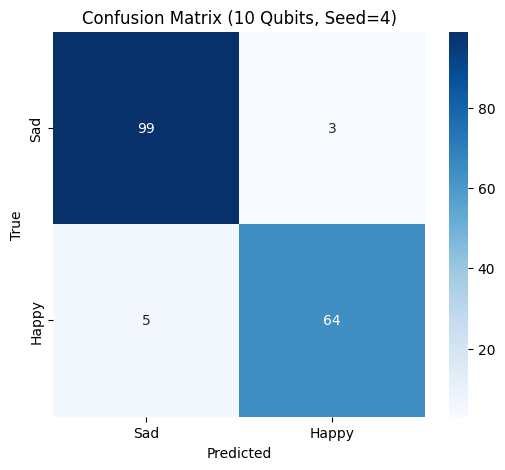

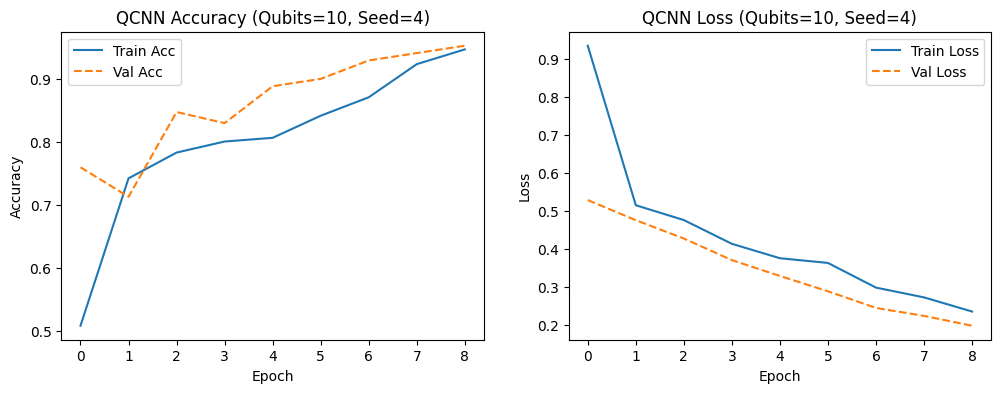


Summary for 10 Qubits:
  Accuracy : 0.9345 ± 0.0285 (95% CI: [0.8949, 0.9741])
  AUC      : 0.9838 ± 0.0102 (95% CI: [0.9697, 0.9979])
  Macro F1 : 0.9316 ± 0.0299 (95% CI: [0.8902, 0.9730])
Running experiments for 12 Qubits

Running seed 0 for 12 qubits 
Epoch 1/9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 3s - 489ms/step - accuracy: 0.5614 - loss: 0.9143 - val_accuracy: 0.7778 - val_loss: 0.4712
Epoch 2/9
6/6 - 0s - 15ms/step - accuracy: 0.7602 - loss: 0.4908 - val_accuracy: 0.8012 - val_loss: 0.3974
Epoch 3/9
6/6 - 0s - 15ms/step - accuracy: 0.7602 - loss: 0.4886 - val_accuracy: 0.8596 - val_loss: 0.3298
Epoch 4/9
6/6 - 0s - 15ms/step - accuracy: 0.8129 - loss: 0.3474 - val_accuracy: 0.9064 - val_loss: 0.2667
Epoch 5/9
6/6 - 0s - 15ms/step - accuracy: 0.8772 - loss: 0.2597 - val_accuracy: 0.9357 - val_loss: 0.2123
Epoch 6/9
6/6 - 0s - 15ms/step - accuracy: 0.9181 - loss: 0.2207 - val_accuracy: 0.9357 - val_loss: 0.1761
Epoch 7/9
6/6 - 0s - 15ms/step - accuracy: 0.9123 - loss: 0.2151 - val_accuracy: 0.9766 - val_loss: 0.1419
Epoch 8/9
6/6 - 0s - 15ms/step - accuracy: 0.9474 - loss: 0.1711 - val_accuracy: 0.9942 - val_loss: 0.1125
Epoch 9/9
6/6 - 0s - 15ms/step - accuracy: 0.9591 - loss: 0.1390 - val_accuracy: 1.0000 - val_loss: 0.0949
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Classif

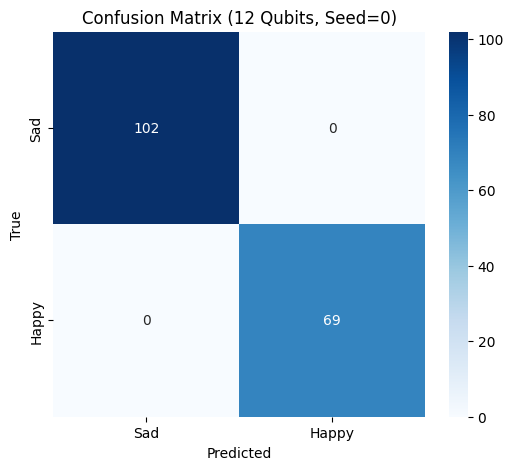

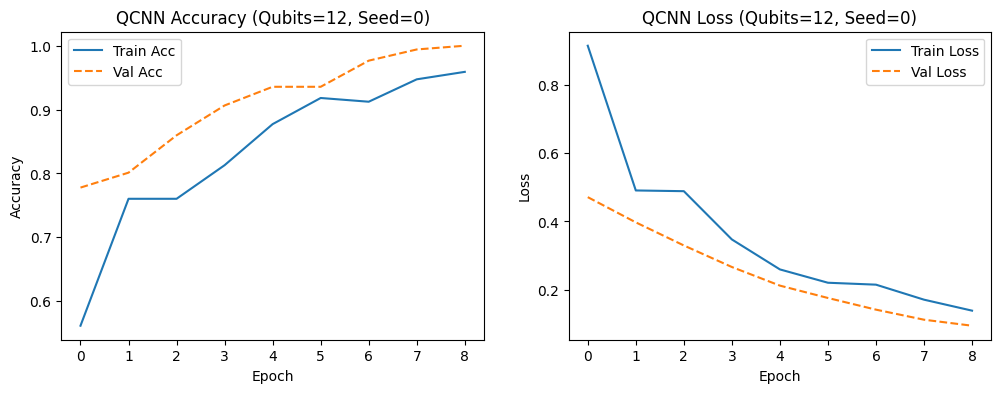


Running seed 1 for 12 qubits 
Epoch 1/9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 3s - 429ms/step - accuracy: 0.5789 - loss: 0.9082 - val_accuracy: 0.7602 - val_loss: 0.5166
Epoch 2/9
6/6 - 0s - 16ms/step - accuracy: 0.7368 - loss: 0.5028 - val_accuracy: 0.7778 - val_loss: 0.4380
Epoch 3/9
6/6 - 0s - 15ms/step - accuracy: 0.7836 - loss: 0.4640 - val_accuracy: 0.8596 - val_loss: 0.3624
Epoch 4/9
6/6 - 0s - 15ms/step - accuracy: 0.8480 - loss: 0.3866 - val_accuracy: 0.8713 - val_loss: 0.3042
Epoch 5/9
6/6 - 0s - 15ms/step - accuracy: 0.8246 - loss: 0.3265 - val_accuracy: 0.9006 - val_loss: 0.2420
Epoch 6/9
6/6 - 0s - 15ms/step - accuracy: 0.8772 - loss: 0.2616 - val_accuracy: 0.9532 - val_loss: 0.1994
Epoch 7/9
6/6 - 0s - 15ms/step - accuracy: 0.9357 - loss: 0.2045 - val_accuracy: 0.9474 - val_loss: 0.1634
Epoch 8/9
6/6 - 0s - 16ms/step - accuracy: 0.9240 - loss: 0.2031 - val_accuracy: 0.9825 - val_loss: 0.1352
Epoch 9/9
6/6 - 0s - 16ms/step - accuracy: 0.9415 - loss: 0.1875 - val_accuracy: 0.9883 - val_loss: 0.1164
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

Classif

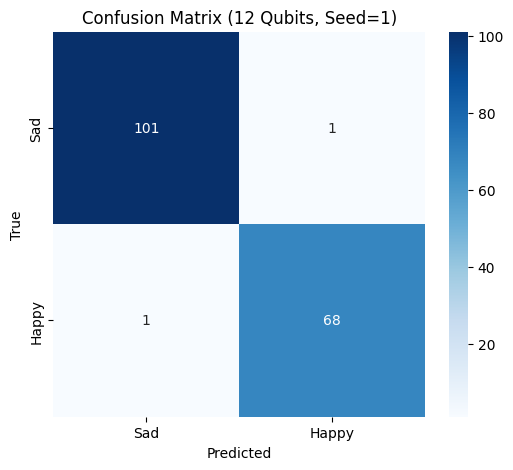

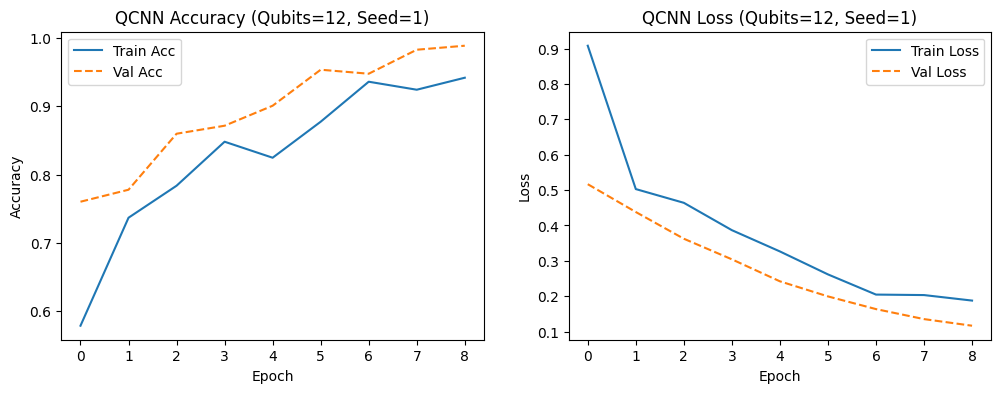


Running seed 2 for 12 qubits 
Epoch 1/9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 3s - 424ms/step - accuracy: 0.5906 - loss: 0.7670 - val_accuracy: 0.7836 - val_loss: 0.5037
Epoch 2/9
6/6 - 0s - 16ms/step - accuracy: 0.7310 - loss: 0.6225 - val_accuracy: 0.8480 - val_loss: 0.3841
Epoch 3/9
6/6 - 0s - 15ms/step - accuracy: 0.8070 - loss: 0.3894 - val_accuracy: 0.8947 - val_loss: 0.3050
Epoch 4/9
6/6 - 0s - 16ms/step - accuracy: 0.8538 - loss: 0.3520 - val_accuracy: 0.8889 - val_loss: 0.2560
Epoch 5/9
6/6 - 0s - 16ms/step - accuracy: 0.9006 - loss: 0.2444 - val_accuracy: 0.9298 - val_loss: 0.2169
Epoch 6/9
6/6 - 0s - 15ms/step - accuracy: 0.9240 - loss: 0.2217 - val_accuracy: 0.9415 - val_loss: 0.1668
Epoch 7/9
6/6 - 0s - 15ms/step - accuracy: 0.9240 - loss: 0.1841 - val_accuracy: 0.9532 - val_loss: 0.1306
Epoch 8/9
6/6 - 0s - 15ms/step - accuracy: 0.9532 - loss: 0.1623 - val_accuracy: 0.9883 - val_loss: 0.1019
Epoch 9/9
6/6 - 0s - 15ms/step - accuracy: 0.9532 - loss: 0.1410 - val_accuracy: 0.9942 - val_loss: 0.0830
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

Classif

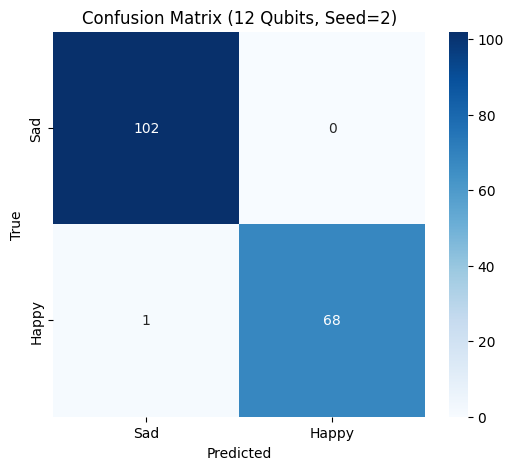

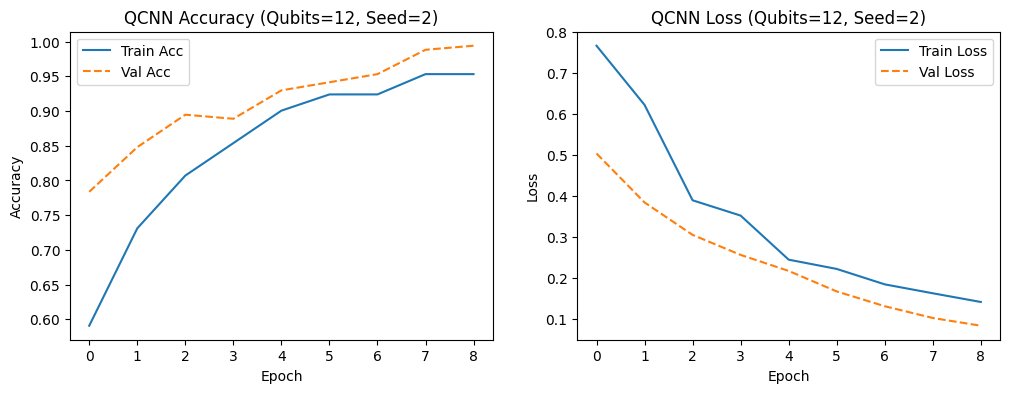


Running seed 3 for 12 qubits 
Epoch 1/9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 3s - 419ms/step - accuracy: 0.5789 - loss: 0.8982 - val_accuracy: 0.6901 - val_loss: 0.5627
Epoch 2/9
6/6 - 0s - 16ms/step - accuracy: 0.7135 - loss: 0.5279 - val_accuracy: 0.7895 - val_loss: 0.4330
Epoch 3/9
6/6 - 0s - 17ms/step - accuracy: 0.7836 - loss: 0.4688 - val_accuracy: 0.8363 - val_loss: 0.3655
Epoch 4/9
6/6 - 0s - 17ms/step - accuracy: 0.8129 - loss: 0.3779 - val_accuracy: 0.8713 - val_loss: 0.3182
Epoch 5/9
6/6 - 0s - 15ms/step - accuracy: 0.8538 - loss: 0.3212 - val_accuracy: 0.8947 - val_loss: 0.2639
Epoch 6/9
6/6 - 0s - 15ms/step - accuracy: 0.9123 - loss: 0.2474 - val_accuracy: 0.9123 - val_loss: 0.2239
Epoch 7/9
6/6 - 0s - 15ms/step - accuracy: 0.9006 - loss: 0.2404 - val_accuracy: 0.9240 - val_loss: 0.1917
Epoch 8/9
6/6 - 0s - 15ms/step - accuracy: 0.9298 - loss: 0.2065 - val_accuracy: 0.9649 - val_loss: 0.1666
Epoch 9/9
6/6 - 0s - 15ms/step - accuracy: 0.9532 - loss: 0.1979 - val_accuracy: 0.9532 - val_loss: 0.1484
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Classif

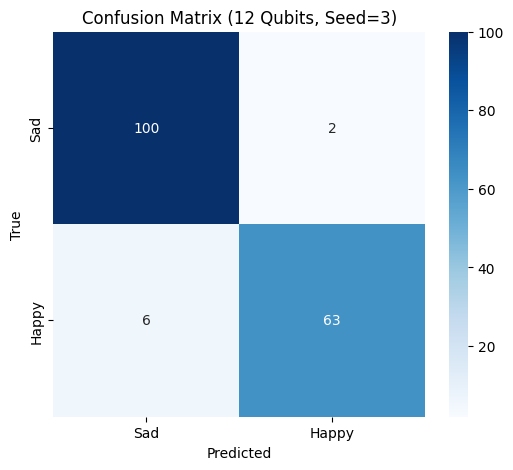

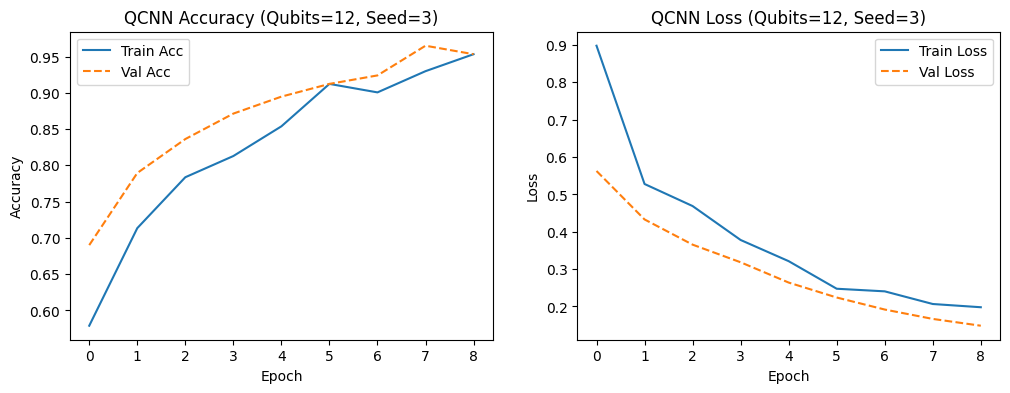


Running seed 4 for 12 qubits 
Epoch 1/9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 3s - 431ms/step - accuracy: 0.6140 - loss: 0.9721 - val_accuracy: 0.6491 - val_loss: 0.6093
Epoch 2/9
6/6 - 0s - 15ms/step - accuracy: 0.6842 - loss: 0.5965 - val_accuracy: 0.7719 - val_loss: 0.4485
Epoch 3/9
6/6 - 0s - 15ms/step - accuracy: 0.7602 - loss: 0.4895 - val_accuracy: 0.8246 - val_loss: 0.3938
Epoch 4/9
6/6 - 0s - 16ms/step - accuracy: 0.8538 - loss: 0.3838 - val_accuracy: 0.8772 - val_loss: 0.3370
Epoch 5/9
6/6 - 0s - 16ms/step - accuracy: 0.8772 - loss: 0.3296 - val_accuracy: 0.8655 - val_loss: 0.2966
Epoch 6/9
6/6 - 0s - 16ms/step - accuracy: 0.8889 - loss: 0.3001 - val_accuracy: 0.9415 - val_loss: 0.2512
Epoch 7/9
6/6 - 0s - 16ms/step - accuracy: 0.9123 - loss: 0.2880 - val_accuracy: 0.9123 - val_loss: 0.2284
Epoch 8/9
6/6 - 0s - 16ms/step - accuracy: 0.8889 - loss: 0.2742 - val_accuracy: 0.9708 - val_loss: 0.1931
Epoch 9/9
6/6 - 0s - 16ms/step - accuracy: 0.9532 - loss: 0.2173 - val_accuracy: 0.9591 - val_loss: 0.1642
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Classif

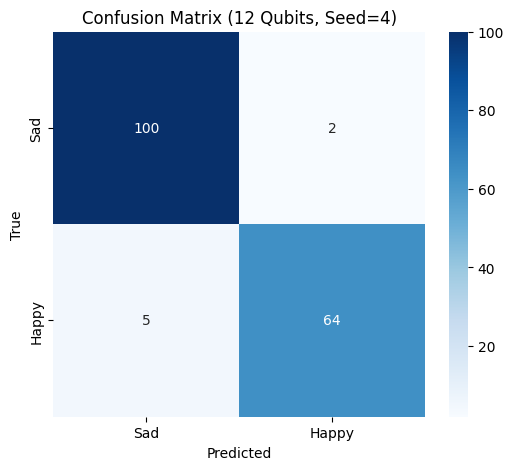

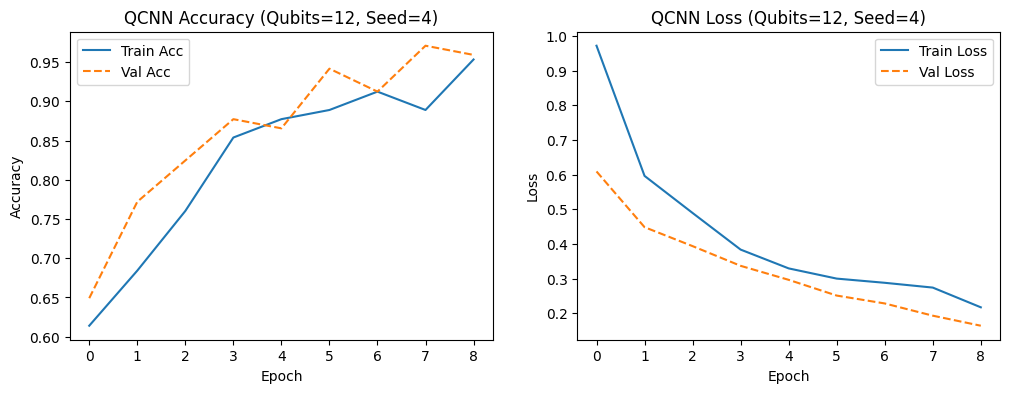


Summary for 12 Qubits:
  Accuracy : 0.9789 ± 0.0191 (95% CI: [0.9525, 1.0054])
  AUC      : 0.9981 ± 0.0020 (95% CI: [0.9953, 1.0009])
  Macro F1 : 0.9780 ± 0.0200 (95% CI: [0.9502, 1.0057])


In [4]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane.templates import RandomLayers
import scipy.stats as st
from collections import Counter


EMOTIONS = ['Sad', 'Happy']   # Only two classes

qubit_patch_shapes = {
    10: (5,2),
    12: (6,2)}

n_epochs = 9
seeds = [0, 1, 2, 3, 4]
qubit_list = [10,12]


print("Train set class counts:")
train_counts = Counter(train_labels)
for i, cls in enumerate(EMOTIONS):
    print(f"  {cls:10s}: {train_counts.get(i, 0)} samples")

print("\nTest set class counts:")
test_counts = Counter(test_labels)
for i, cls in enumerate(EMOTIONS):
    print(f"  {cls:10s}: {test_counts.get(i, 0)} samples")


def create_circuit(n_qubits, n_layers=3):
    dev = qml.device("default.qubit", wires=n_qubits)
    rand_params = np.random.uniform(high=2*np.pi, size=(n_layers, n_qubits))

    @qml.qnode(dev)
    def circuit(phi):
        for j in range(n_qubits):
            qml.RY(np.pi * phi[j], wires=j)
        RandomLayers(rand_params, wires=range(n_qubits))
        return [qml.expval(qml.PauliZ(j)) for j in range(n_qubits)]
    
    return circuit


def quanv(image, circuit, patch_h, patch_w):
    out_h = (image.shape[0] - patch_h) // 2 + 1
    out_w = (image.shape[1] - patch_w) // 2 + 1
    n_qubits = patch_h * patch_w
    out = np.zeros((out_h, out_w, n_qubits))

    for j in range(0, image.shape[0] - patch_h + 1, 2):
        for k in range(0, image.shape[1] - patch_w + 1, 2):
            patch = image[j:j+patch_h, k:k+patch_w, 0].flatten()
            out[j//2, k//2, :] = circuit(patch)
    return out


for q in qubit_list:
    print(f"Running experiments for {q} Qubits")

    # Initialize storage for results
    acc_list, auc_list, f1_list = [], [], []

    patch_h, patch_w = qubit_patch_shapes[q]
    circuit = create_circuit(q)

    # Run across all random seeds
    for seed in seeds:
        print(f"\nRunning seed {seed} for {q} qubits ")
        np.random.seed(seed)
        tf.random.set_seed(seed)

        # Quantum feature mapping
        q_train = np.array([quanv(img, circuit, patch_h, patch_w) for img in train_images])
        q_test = np.array([quanv(img, circuit, patch_h, patch_w) for img in test_images])

        # Classical NN on quantum features
        model = keras.Sequential([
            keras.layers.Flatten(input_shape=q_train.shape[1:]),
            keras.layers.Dense(64, activation='relu'),
            keras.layers.Dropout(0.3),
            keras.layers.Dense(1, activation='sigmoid')  # Binary classification
        ])
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        history = model.fit(q_train, train_labels,
                            validation_data=(q_test, test_labels),
                            epochs=n_epochs, batch_size=32, verbose=2)

        # Predictions
        y_pred_prob = model.predict(q_test).flatten()
        y_pred = (y_pred_prob > 0.5).astype(int)

        # Evaluation metrics
        auc = roc_auc_score(test_labels, y_pred_prob)
        macro_f1 = f1_score(test_labels, y_pred, average='macro')
        acc = np.mean(y_pred == test_labels)

        acc_list.append(acc)
        auc_list.append(auc)
        f1_list.append(macro_f1)

        # Classification Report
        print("\nClassification Report:")
        print(classification_report(test_labels, y_pred, target_names=EMOTIONS))

        # Confusion Matrix
        cm = confusion_matrix(test_labels, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=EMOTIONS, yticklabels=EMOTIONS)
        plt.title(f"Confusion Matrix ({q} Qubits, Seed={seed})")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()

        # Accuracy/Loss Curves
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(history.history['accuracy'], label='Train Acc')
        plt.plot(history.history['val_accuracy'], '--', label='Val Acc')
        plt.title(f"QCNN Accuracy (Qubits={q}, Seed={seed})")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'], label='Train Loss')
        plt.plot(history.history['val_loss'], '--', label='Val Loss')
        plt.title(f"QCNN Loss (Qubits={q}, Seed={seed})")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.show()

    # Compute summary statistics
    acc_arr, auc_arr, f1_arr = np.array(acc_list), np.array(auc_list), np.array(f1_list)

    mean_acc, std_acc = acc_arr.mean(), acc_arr.std()
    mean_auc, std_auc = auc_arr.mean(), auc_arr.std()
    mean_f1, std_f1 = f1_arr.mean(), f1_arr.std()

    ci_acc = st.t.interval(0.95, len(acc_arr)-1, loc=mean_acc, scale=st.sem(acc_arr))
    ci_auc = st.t.interval(0.95, len(auc_arr)-1, loc=mean_auc, scale=st.sem(auc_arr))
    ci_f1 = st.t.interval(0.95, len(f1_arr)-1, loc=mean_f1, scale=st.sem(f1_arr))

    print(f"\nSummary for {q} Qubits:")
    print(f"  Accuracy : {mean_acc:.4f} ± {std_acc:.4f} (95% CI: [{ci_acc[0]:.4f}, {ci_acc[1]:.4f}])")
    print(f"  AUC      : {mean_auc:.4f} ± {std_auc:.4f} (95% CI: [{ci_auc[0]:.4f}, {ci_auc[1]:.4f}])")
    print(f"  Macro F1 : {mean_f1:.4f} ± {std_f1:.4f} (95% CI: [{ci_f1[0]:.4f}, {ci_f1[1]:.4f}])")


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

train_labels_cat = to_categorical(train_labels, num_classes=len(EMOTIONS))
test_labels_cat = to_categorical(test_labels, num_classes=len(EMOTIONS))

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(EMOTIONS), activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
c_history = cnn_model.fit(train_images, train_labels_cat,
                          validation_data=(test_images, test_labels_cat),
                          epochs=n_epochs, batch_size=32, verbose=2)

# CNN metrics
y_pred_prob = cnn_model.predict(test_images)
y_pred = np.argmax(y_pred_prob, axis=1)
macro_auc_cnn = roc_auc_score(test_labels_cat, y_pred_prob, multi_class='ovr', average='macro')
macro_f1_cnn = f1_score(test_labels, y_pred, average='macro')
test_loss, test_acc = cnn_model.evaluate(test_images, test_labels_cat, verbose=0)

print(f"\nCNN Test Accuracy: {test_acc:.4f}")
print(f"CNN Macro ROC-AUC : {macro_auc_cnn:.4f}")
print(f"CNN Macro F1-score: {macro_f1_cnn:.4f}")


Epoch 1/9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 - 6s - 996ms/step - accuracy: 0.5380 - loss: 0.7068 - val_accuracy: 0.5965 - val_loss: 0.6497
Epoch 2/9
6/6 - 0s - 17ms/step - accuracy: 0.5965 - loss: 0.6482 - val_accuracy: 0.5965 - val_loss: 0.6403
Epoch 3/9
6/6 - 0s - 16ms/step - accuracy: 0.6023 - loss: 0.6391 - val_accuracy: 0.6257 - val_loss: 0.6195
Epoch 4/9
6/6 - 0s - 17ms/step - accuracy: 0.6316 - loss: 0.6117 - val_accuracy: 0.6667 - val_loss: 0.5914
Epoch 5/9
6/6 - 0s - 17ms/step - accuracy: 0.7193 - loss: 0.5821 - val_accuracy: 0.7076 - val_loss: 0.5528
Epoch 6/9
6/6 - 0s - 17ms/step - accuracy: 0.7427 - loss: 0.5502 - val_accuracy: 0.7895 - val_loss: 0.5123
Epoch 7/9
6/6 - 0s - 17ms/step - accuracy: 0.7778 - loss: 0.4932 - val_accuracy: 0.7836 - val_loss: 0.4621
Epoch 8/9
6/6 - 0s - 17ms/step - accuracy: 0.8246 - loss: 0.4814 - val_accuracy: 0.8246 - val_loss: 0.4206
Epoch 9/9
6/6 - 0s - 17ms/step - accuracy: 0.8304 - loss: 0.4217 - val_accuracy: 0.8655 - val_loss: 0.3873
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step

CNN Tes

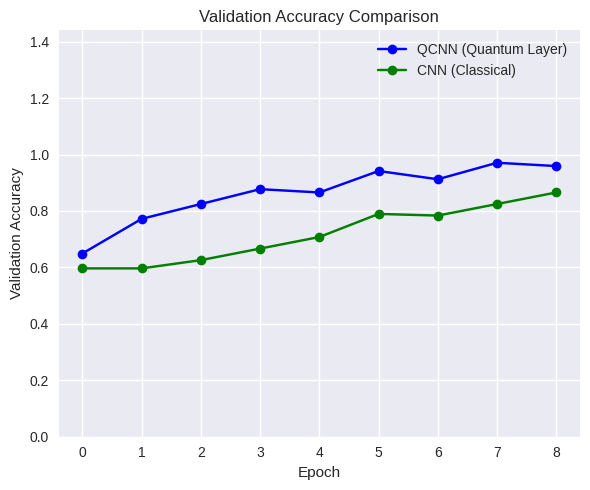

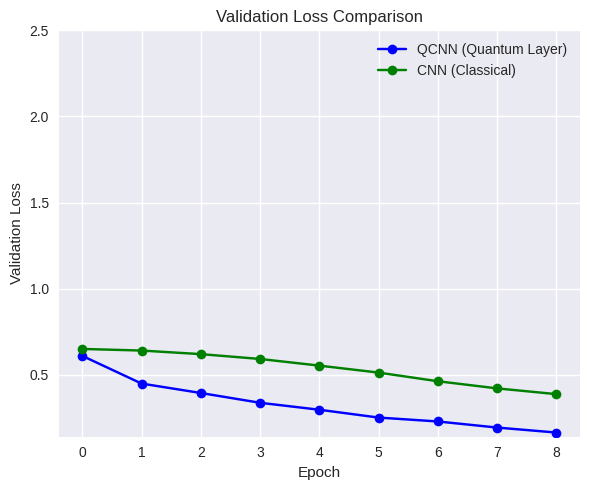

In [6]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")


plt.figure(figsize=(6, 5))
plt.plot(history.history["val_accuracy"], "-ob", label="QCNN (Quantum Layer)")
plt.plot(c_history.history["val_accuracy"], "-og", label="CNN (Classical)")
plt.ylabel("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylim([0, 1.44])
plt.legend()
plt.title("Validation Accuracy Comparison")
plt.tight_layout()
plt.savefig("val_accuracy_comparison.png", dpi=300)
plt.show()


plt.figure(figsize=(6, 5))
plt.plot(history.history["val_loss"], "-ob", label="QCNN (Quantum Layer)")
plt.plot(c_history.history["val_loss"], "-og", label="CNN (Classical)")
plt.ylabel("Validation Loss")
plt.xlabel("Epoch")
plt.ylim(top=2.5)
plt.legend()
plt.title("Validation Loss Comparison")
plt.tight_layout()
plt.savefig("val_loss_comparison.png", dpi=300)
plt.show()